---
# In this file, we use diffenrent balmer decrement bins at different redshift bins to see how the dust curve changes with redshift.

In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

458


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}


In [2]:
redshift_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue


    continuum_dict=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
    lines_dict=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

    balmer_ratio_uncertainty=FL.BalmerDecrementUncertainty(lines_dict['halpha_flux'], lines_dict['halpha_flux_err'], lines_dict['hbeta_flux'], lines_dict['hbeta_flux_err'])

    balmer_ratio=lines_dict['halpha_flux']/lines_dict['hbeta_flux']
    balmer_ratio_snr=balmer_ratio/balmer_ratio_uncertainty

    uv_slope=continuum_dict['exponent']
    uv_slope_err=continuum_dict['exponent_error']

    balmer_decrement=np.log(balmer_ratio/2.86)
    if balmer_decrement<-0.1:
        continue
    redshift_list.append(catalog['determined_redshift'])

redshift_list=np.array(redshift_list)

In [3]:
len(redshift_list)

375

Text(0.5, 1.0, 'Redshift Distribution of Sample Galaxies')

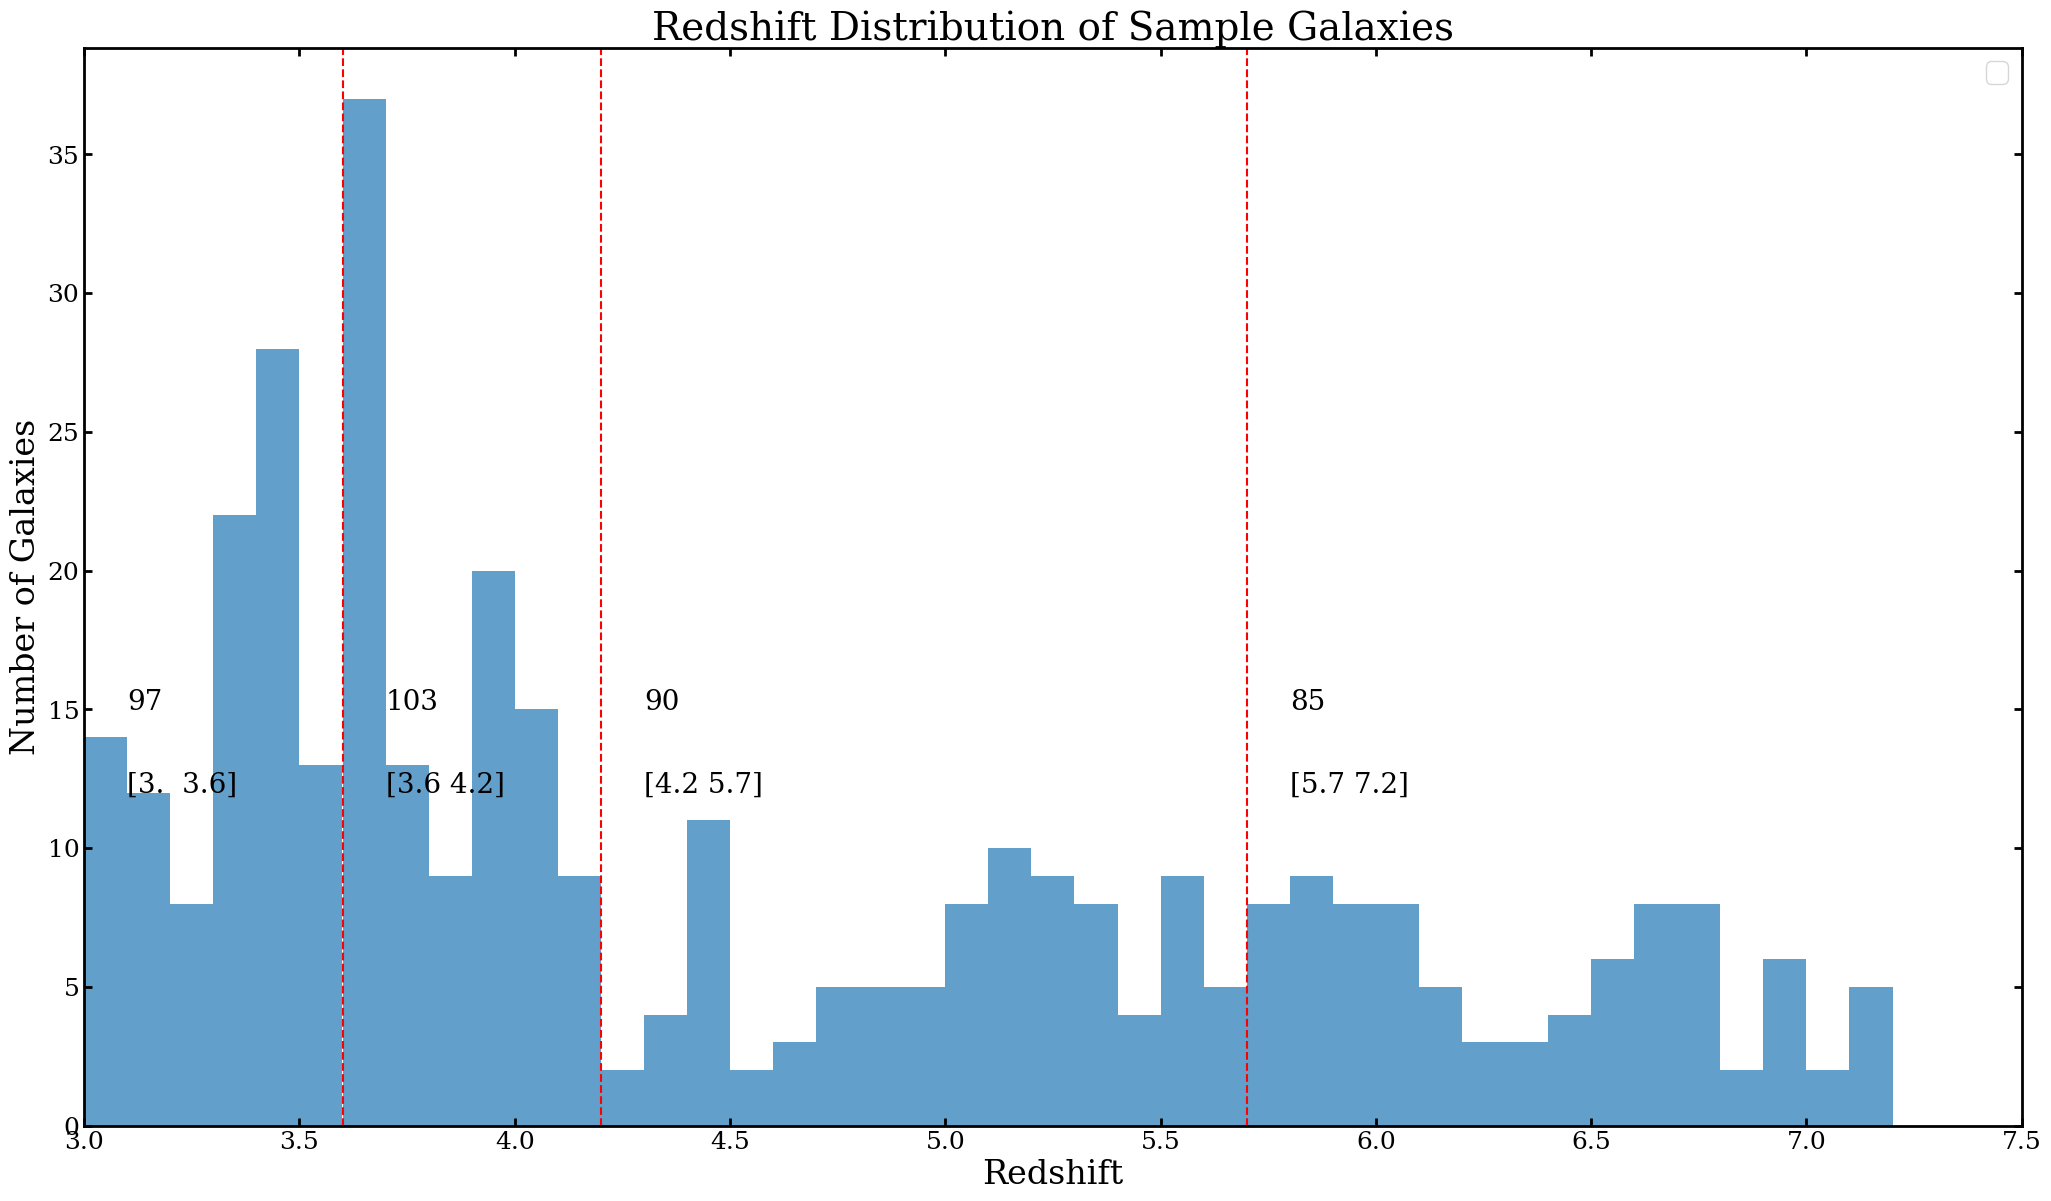

In [36]:
redshift_conditions=np.array([[3,3.6],[3.6,4.2],[4.2,5.7],[5.7,7.2]])
fig, ax=plt.subplots(figsize=(25,14))

ax.hist(redshift_list, bins=50,range=(3,8), alpha=0.7)
ax.set_xlabel('Redshift',fontsize=24)
ax.set_ylabel('Number of Galaxies',fontsize=24)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.legend(fontsize=20, loc='best')
ax.set_xlim(3,7.5)
for bin_edge in redshift_conditions:
    ax.axvline(bin_edge[0], color='r', linestyle='dashed')
    ax.text(bin_edge[0]+0.1, 15, f'{np.sum((redshift_list >= bin_edge[0]) & (redshift_list < bin_edge[1]))}', color='k', fontsize=20)
    ax.text(bin_edge[0]+0.1, 12, f'{bin_edge}', color='k', fontsize=20)
ax.set_title('Redshift Distribution of Sample Galaxies', fontsize=28)

In [37]:
redshift_conditions=np.array([[3,3.6],[3.6,4.2],[4.2,5.7],[5.7,7.2]])
def redshift_condition_func(z,redshift_conditions=redshift_conditions):
    for i, condition in enumerate(redshift_conditions):
        if condition[0]<=z<condition[1]:
            return i

color=['b','g','r','c','m','y','k']
colors_list=[]
uv_slope_list=[]
uv_slope_err_list=[]
balmer_decrement_list=[]
balmer_decrement_err_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    continuum_dict=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
    lines_dict=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

    balmer_ratio_uncertainty=FL.BalmerDecrementUncertainty(lines_dict['halpha_flux'], lines_dict['halpha_flux_err'], lines_dict['hbeta_flux'], lines_dict['hbeta_flux_err'])

    balmer_ratio=lines_dict['halpha_flux']/lines_dict['hbeta_flux']
    balmer_ratio_snr=balmer_ratio/balmer_ratio_uncertainty

    uv_slope=continuum_dict['exponent']
    uv_slope_err=continuum_dict['exponent_error']

    balmer_decrement=np.log(balmer_ratio/2.86)
    if balmer_decrement<-0.1:
        continue
    redshift_bin_index=redshift_condition_func(catalog['determined_redshift'])
    colors_list.append(color[redshift_bin_index])

    uv_slope_list.append(uv_slope)
    uv_slope_err_list.append(uv_slope_err)
    balmer_decrement_list.append(balmer_decrement)
    balmer_decrement_err_list.append(balmer_ratio_uncertainty / balmer_ratio)

balmer_decrement_array=np.array(balmer_decrement_list)
balmer_decrement_uncertainty_array=np.array(balmer_decrement_err_list)
uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)

In [38]:
def group_condition_func(balmer_decrement, group_conditions):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return None

def linear_func(x, a, b):
    return a*x + b

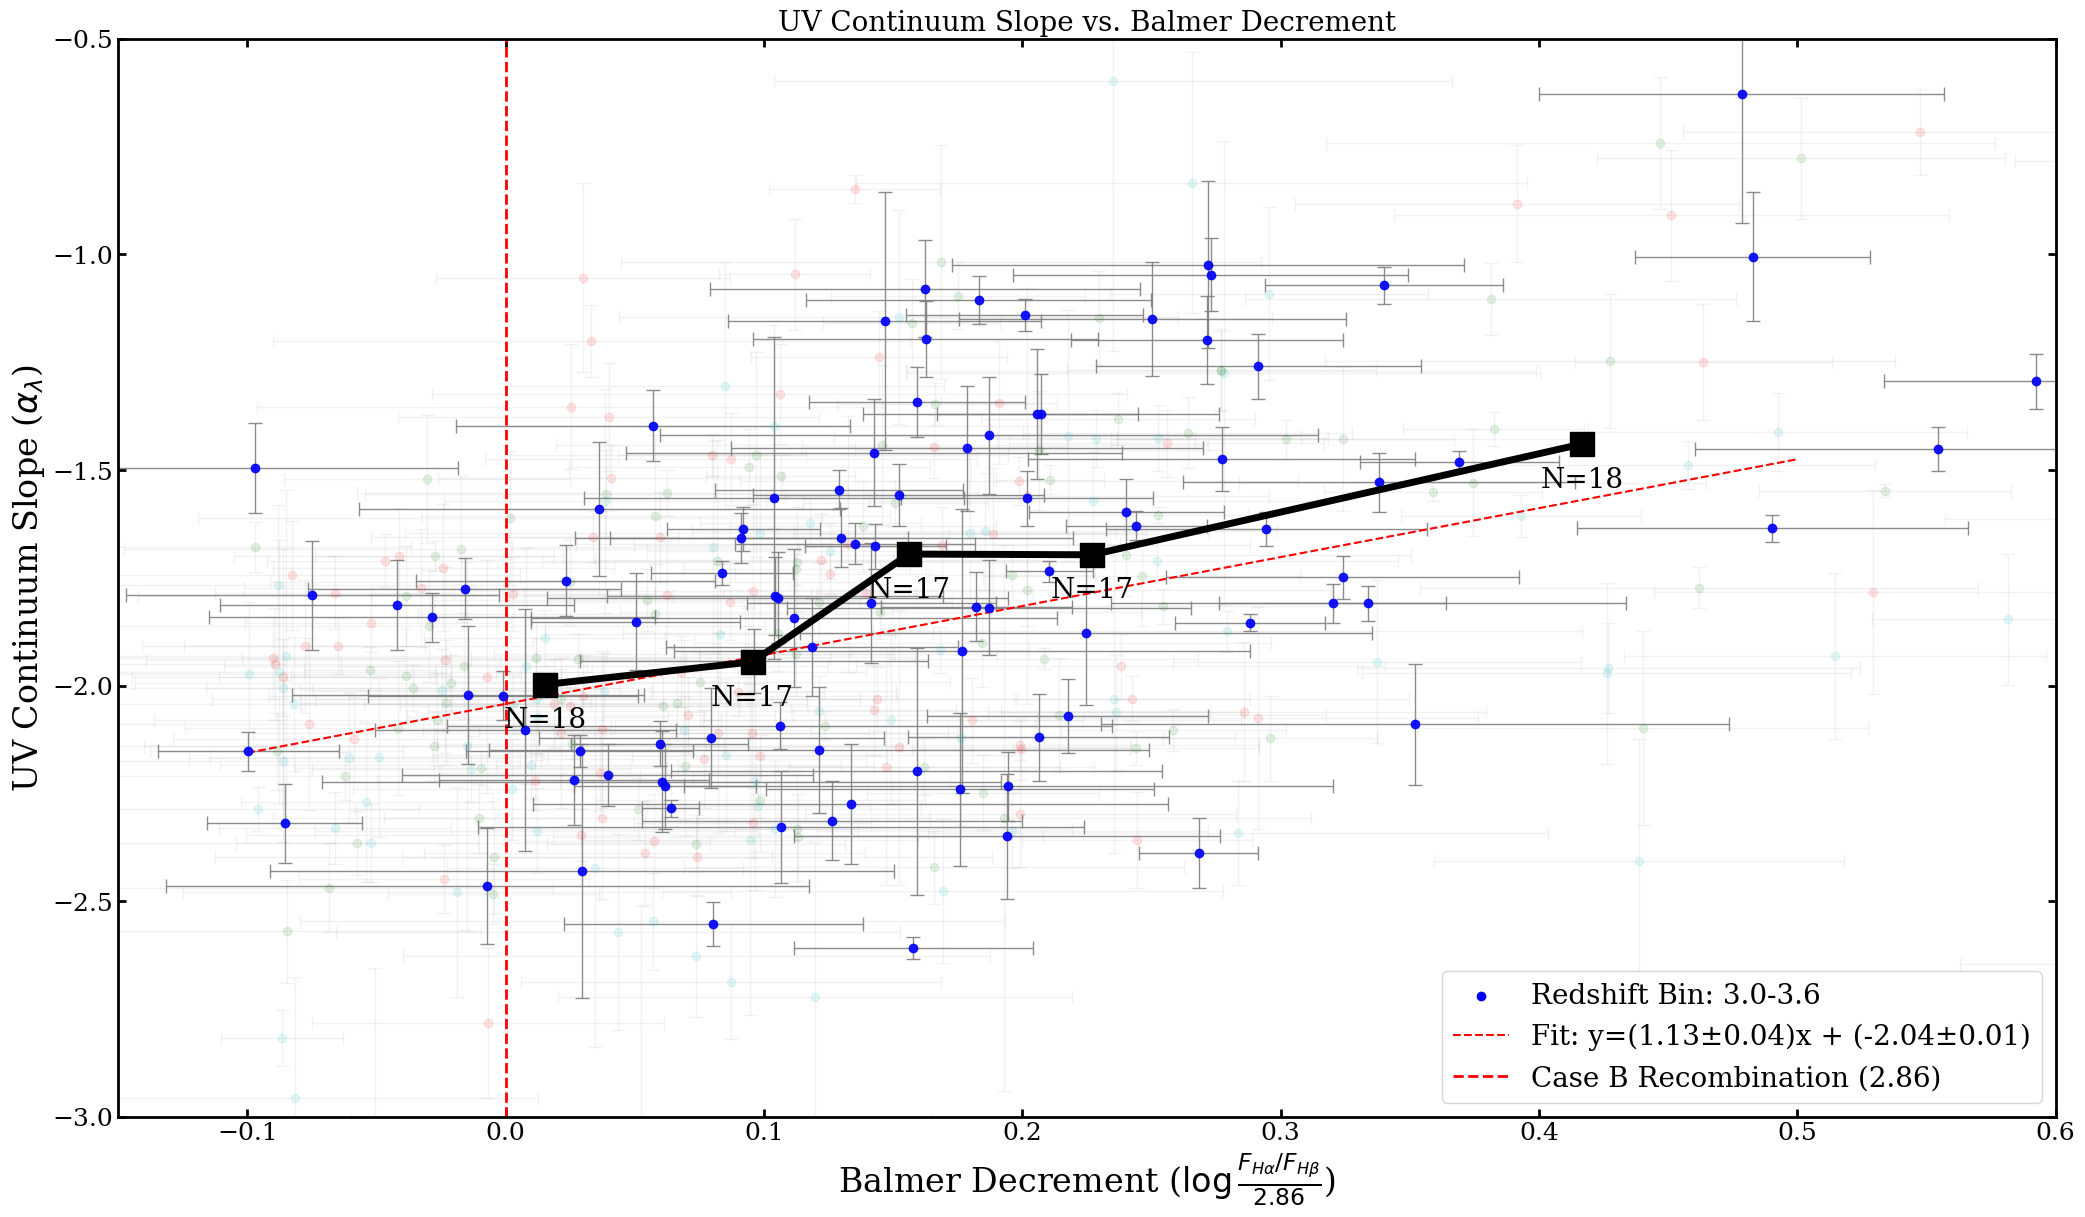

Processing Redshift Bin 3.0-3.6, Group 0, Number of Spectra: 18
Processing Redshift Bin 3.0-3.6, Group 1, Number of Spectra: 17
Processing Redshift Bin 3.0-3.6, Group 2, Number of Spectra: 17
Processing Redshift Bin 3.0-3.6, Group 3, Number of Spectra: 17
Processing Redshift Bin 3.0-3.6, Group 4, Number of Spectra: 18


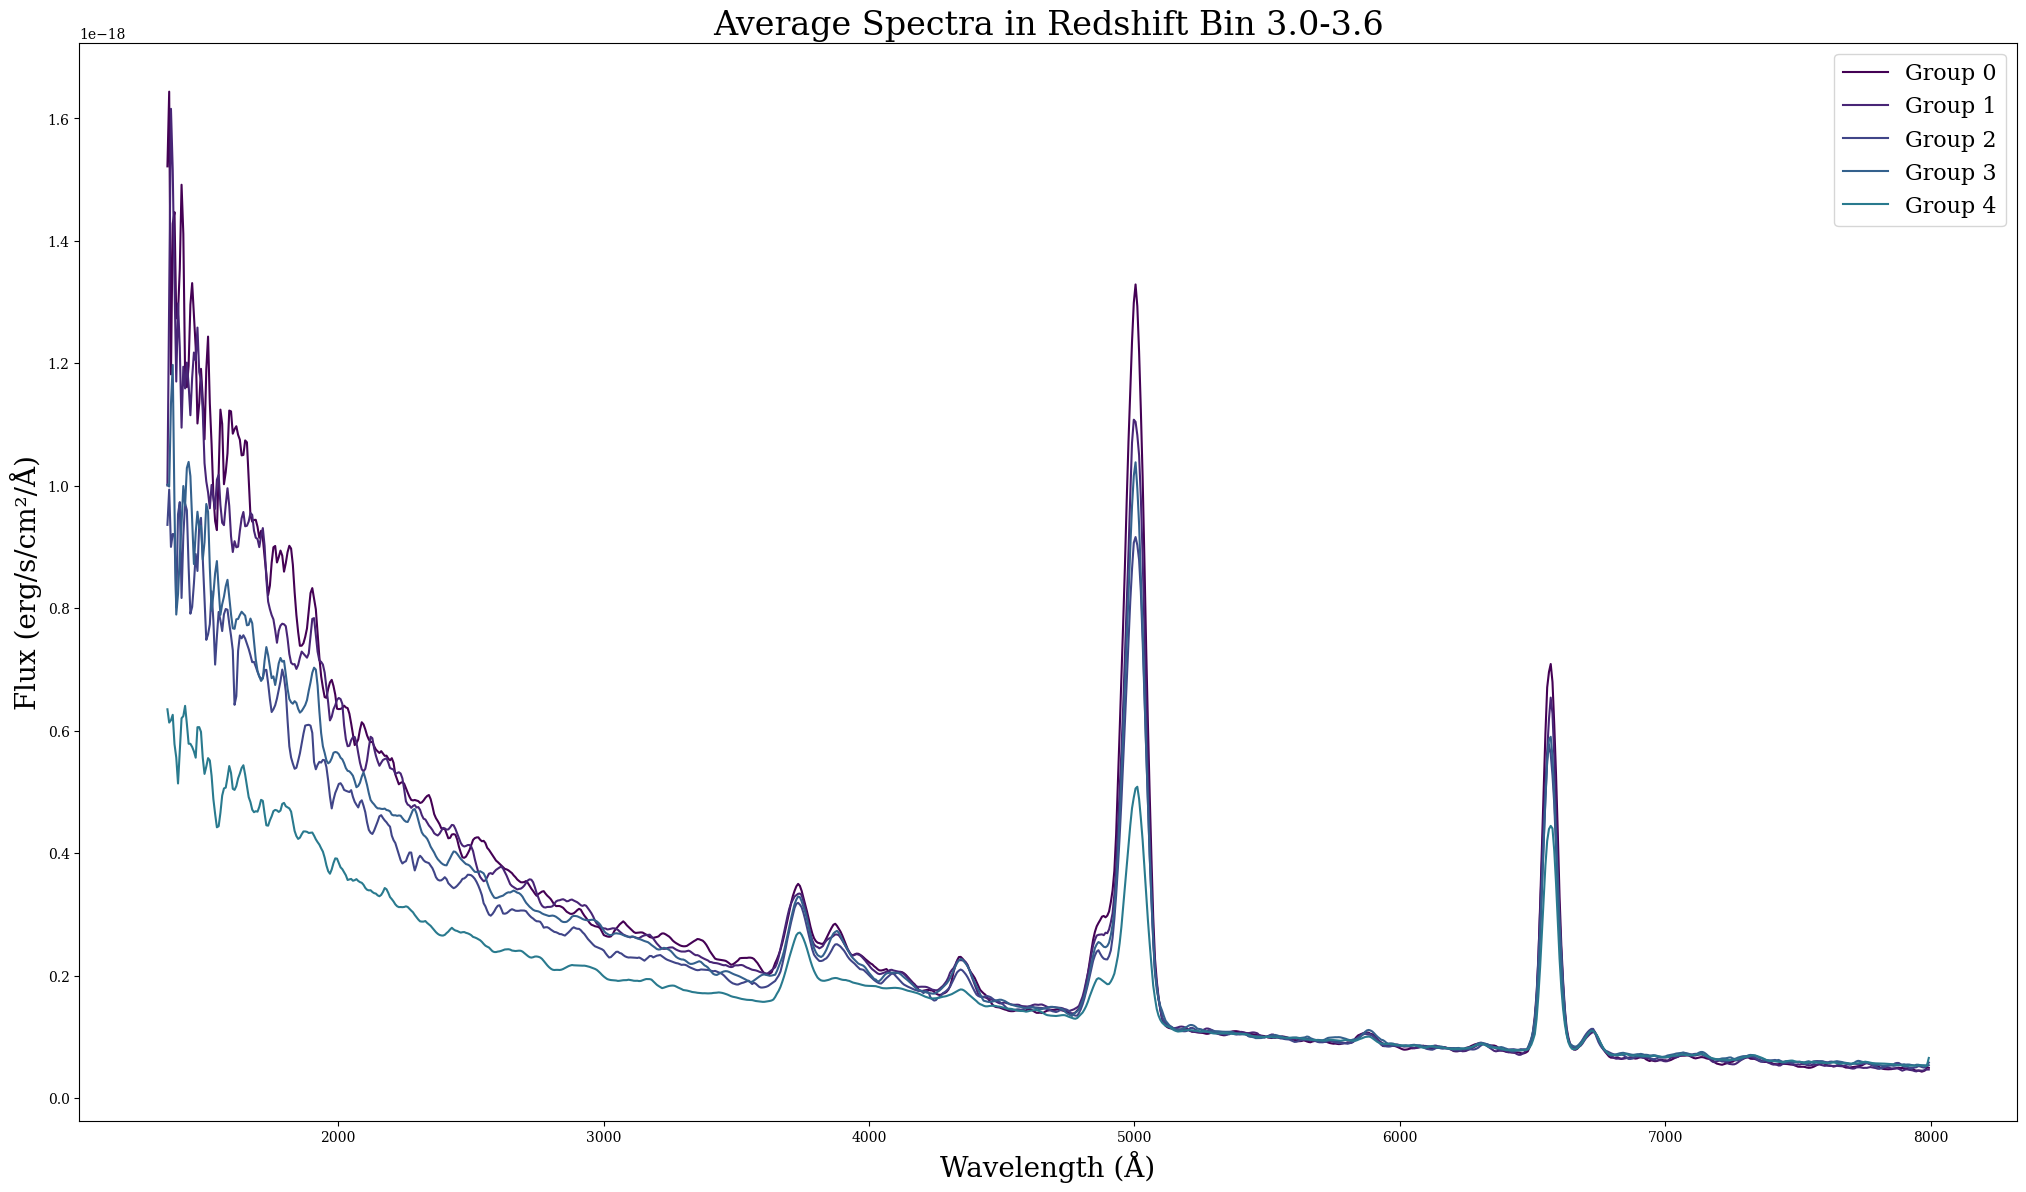

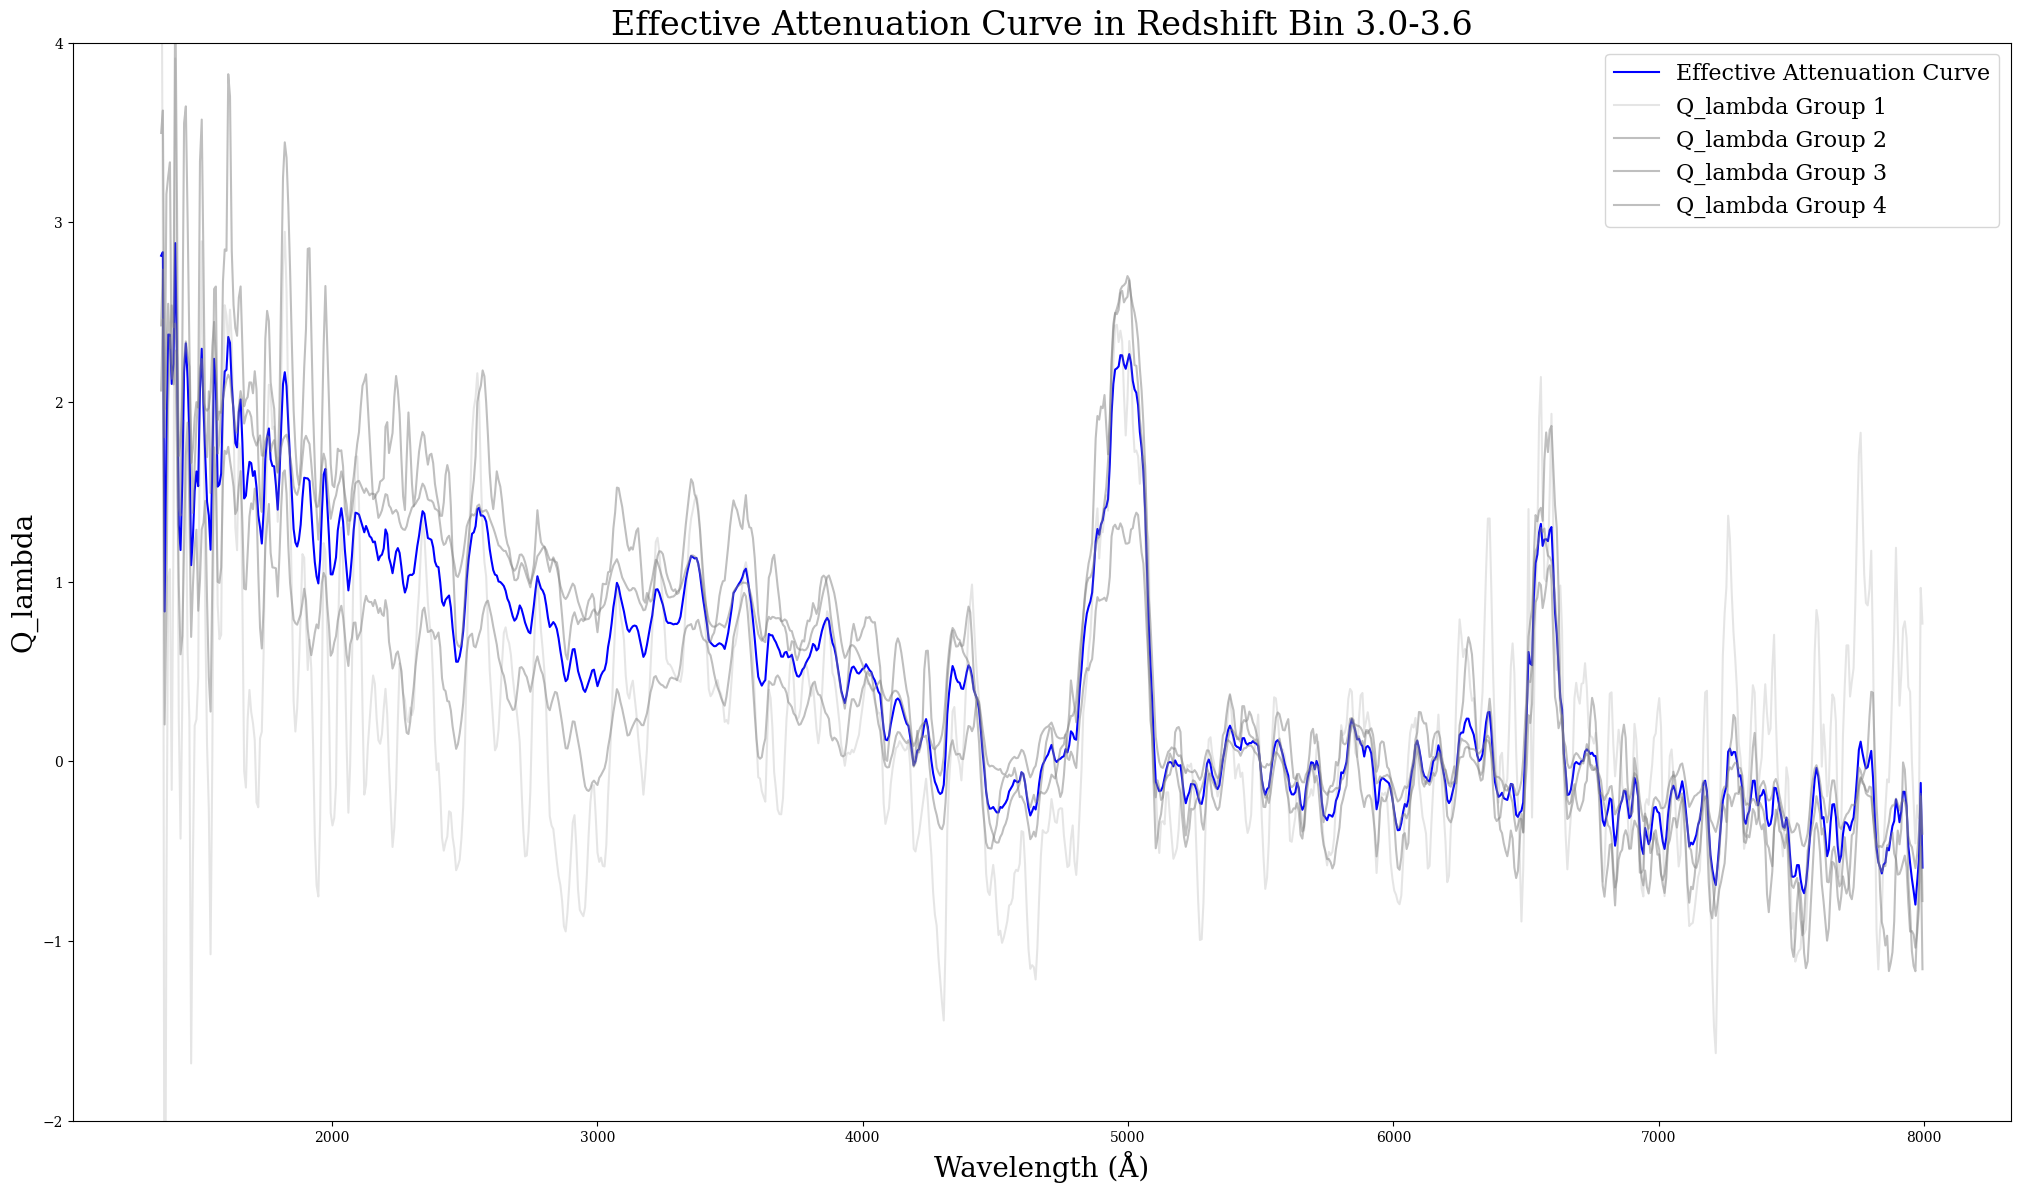

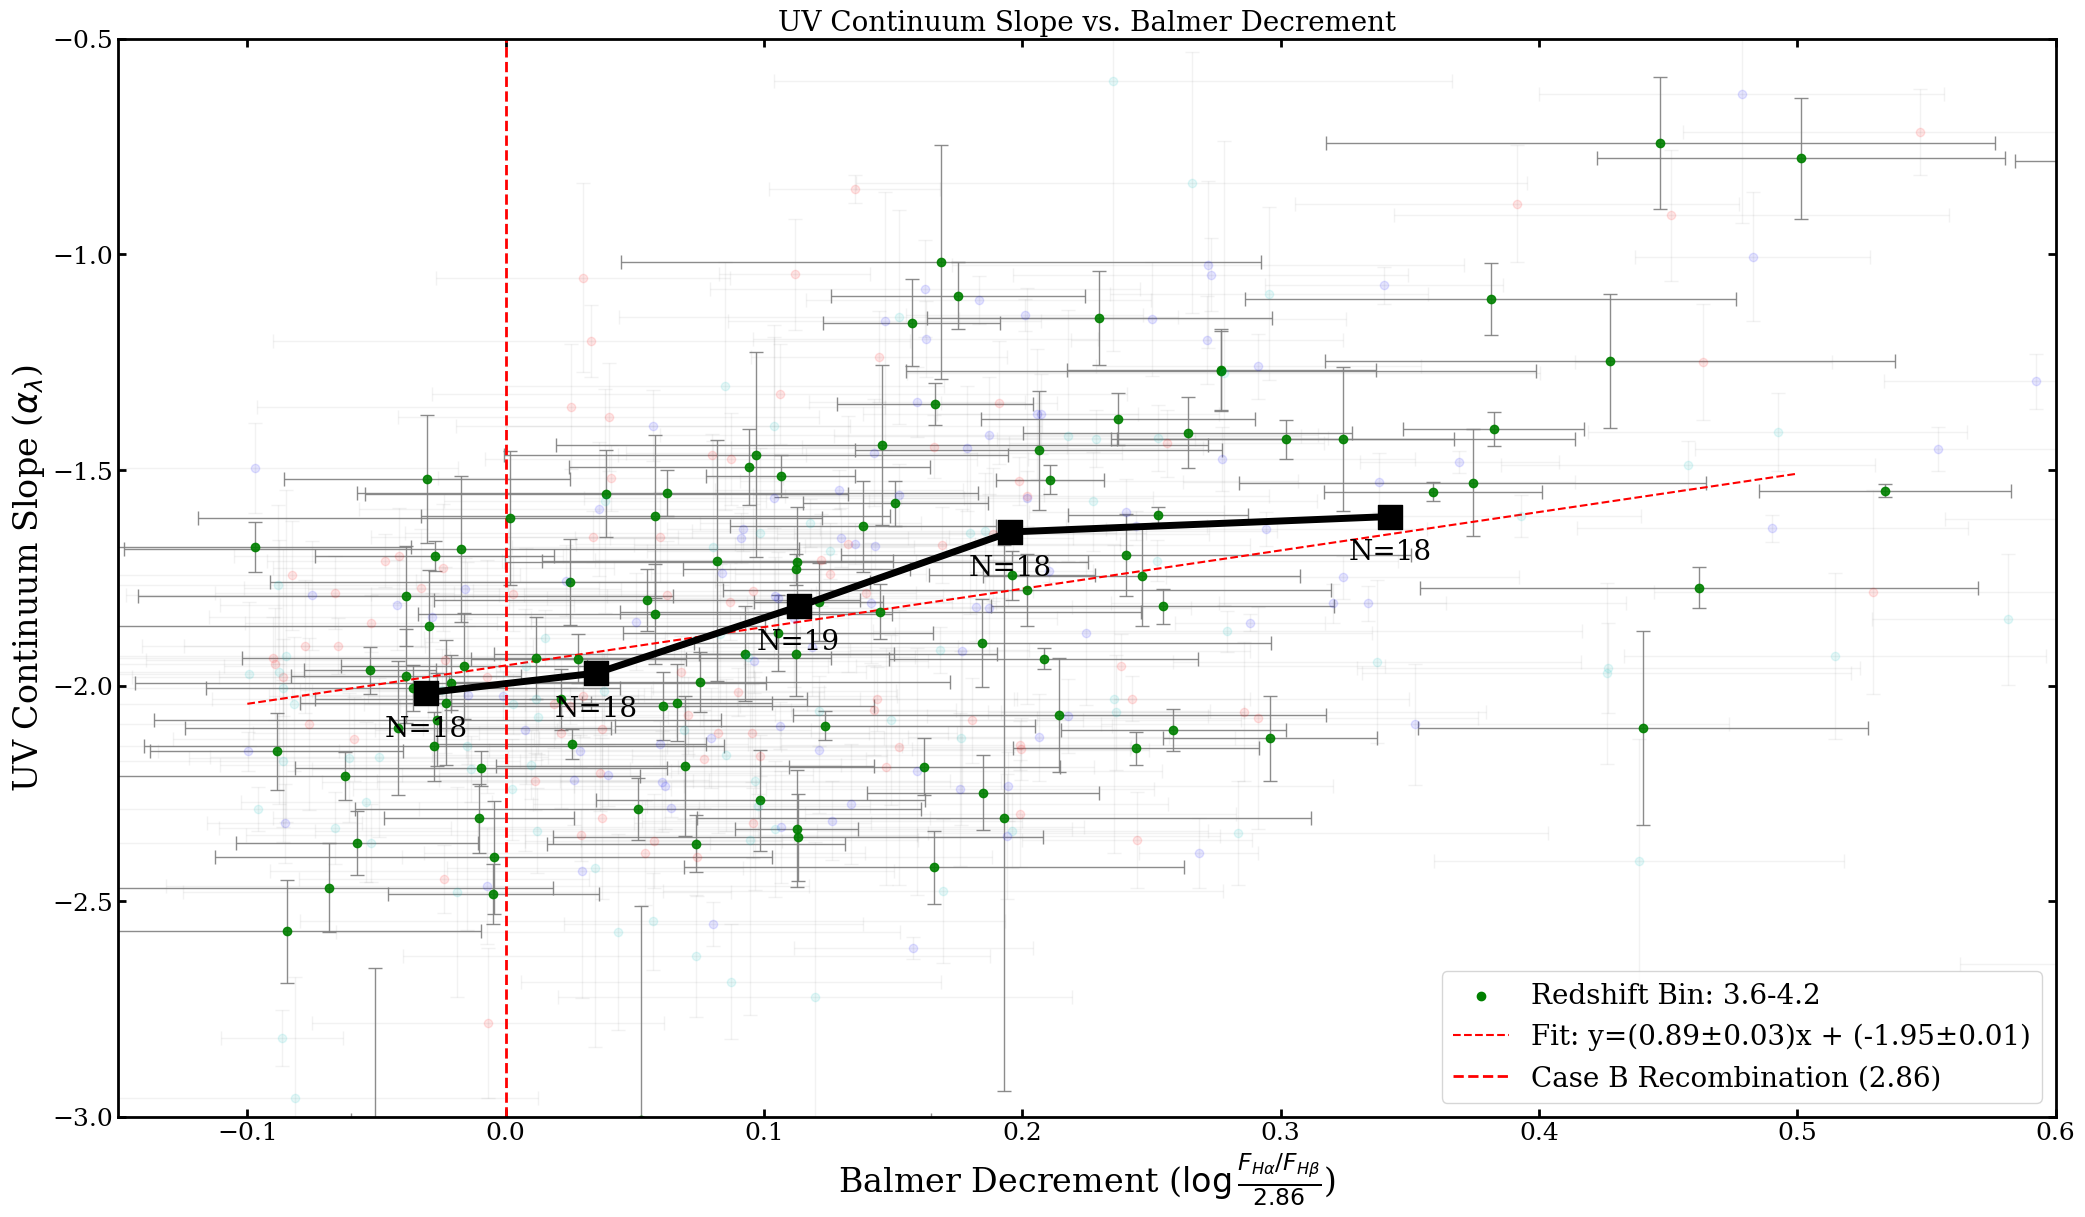

Processing Redshift Bin 3.6-4.2, Group 0, Number of Spectra: 18
Processing Redshift Bin 3.6-4.2, Group 1, Number of Spectra: 18
Processing Redshift Bin 3.6-4.2, Group 2, Number of Spectra: 19
Processing Redshift Bin 3.6-4.2, Group 3, Number of Spectra: 18
Processing Redshift Bin 3.6-4.2, Group 4, Number of Spectra: 18


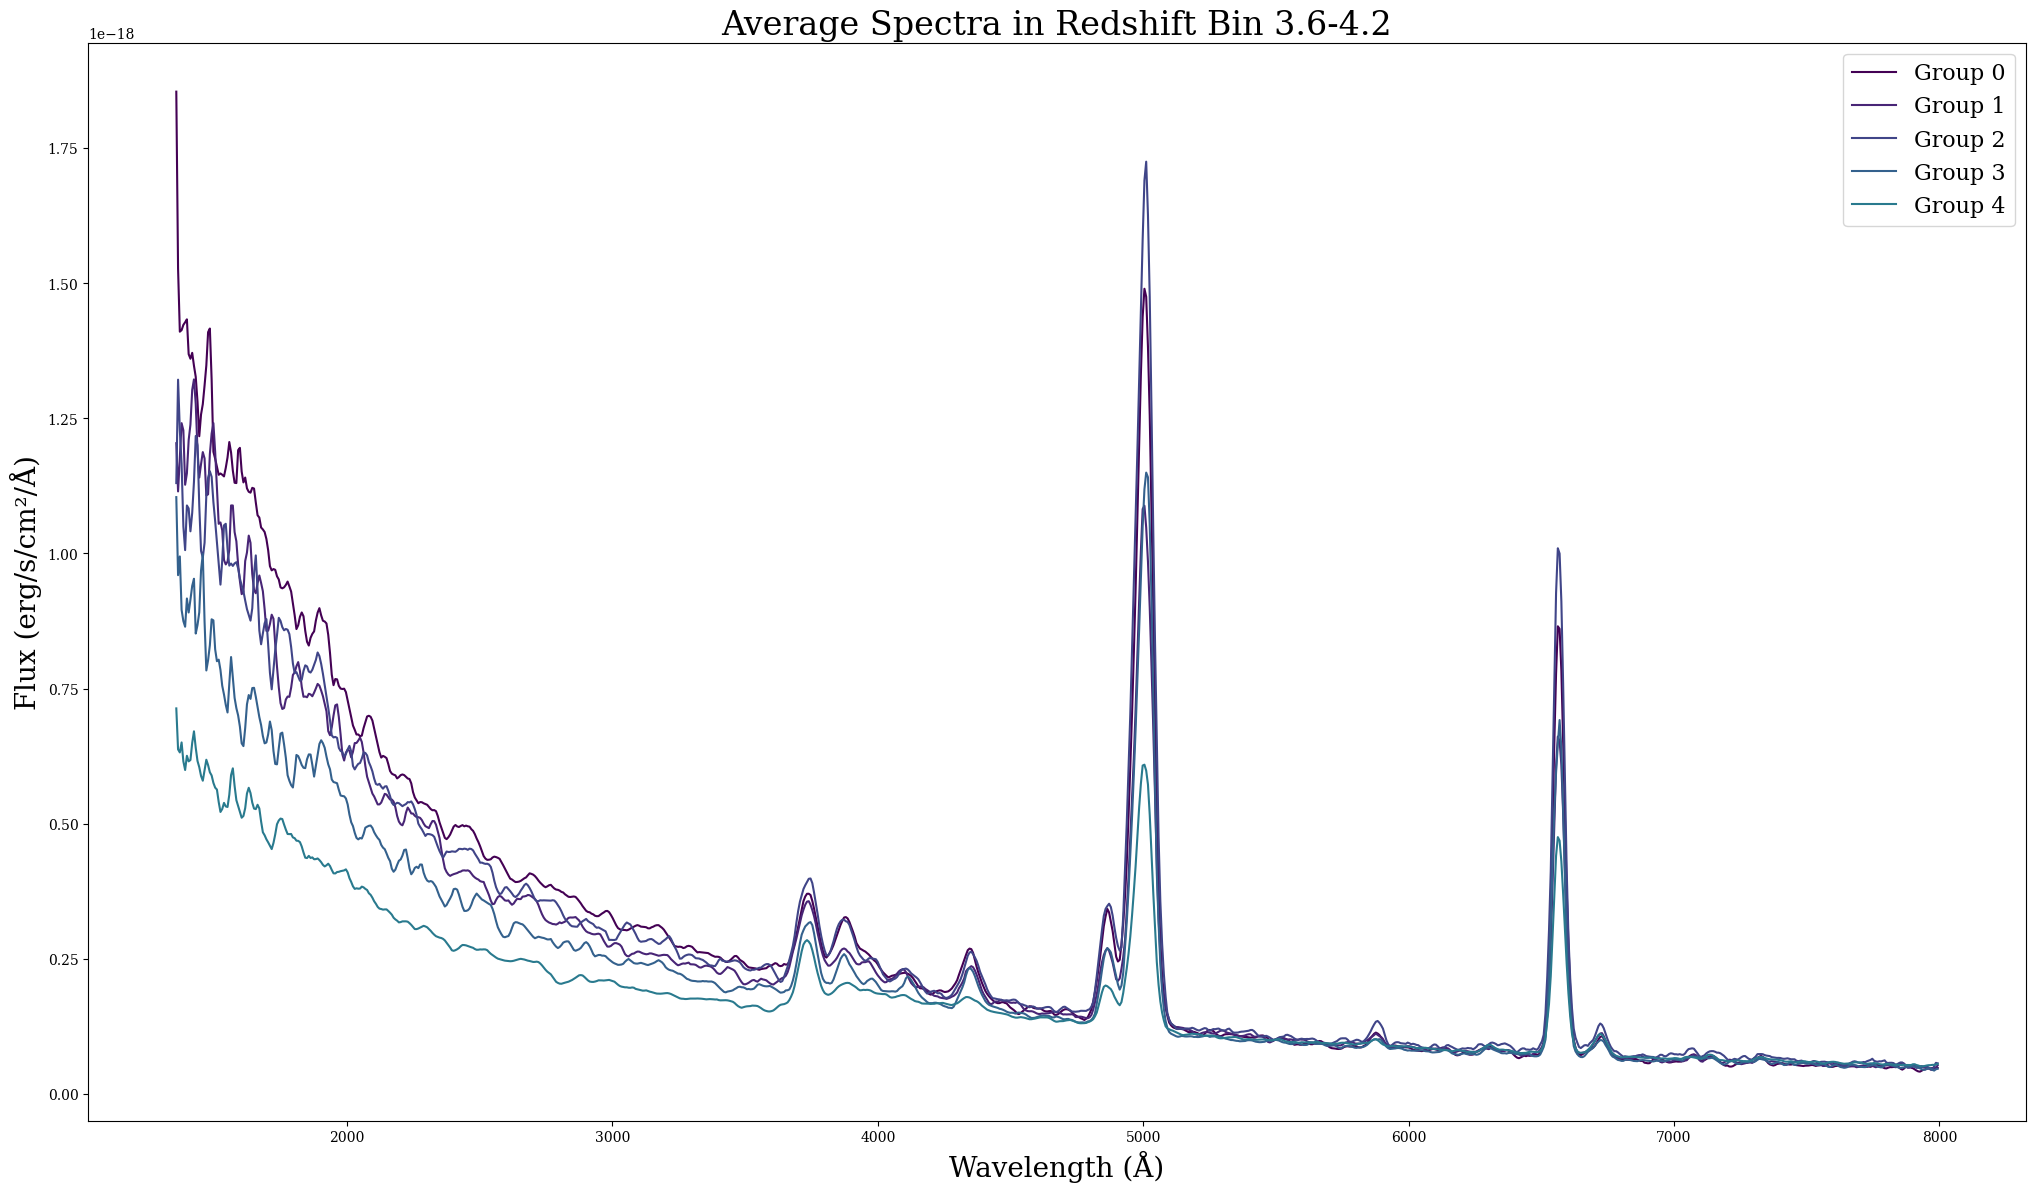

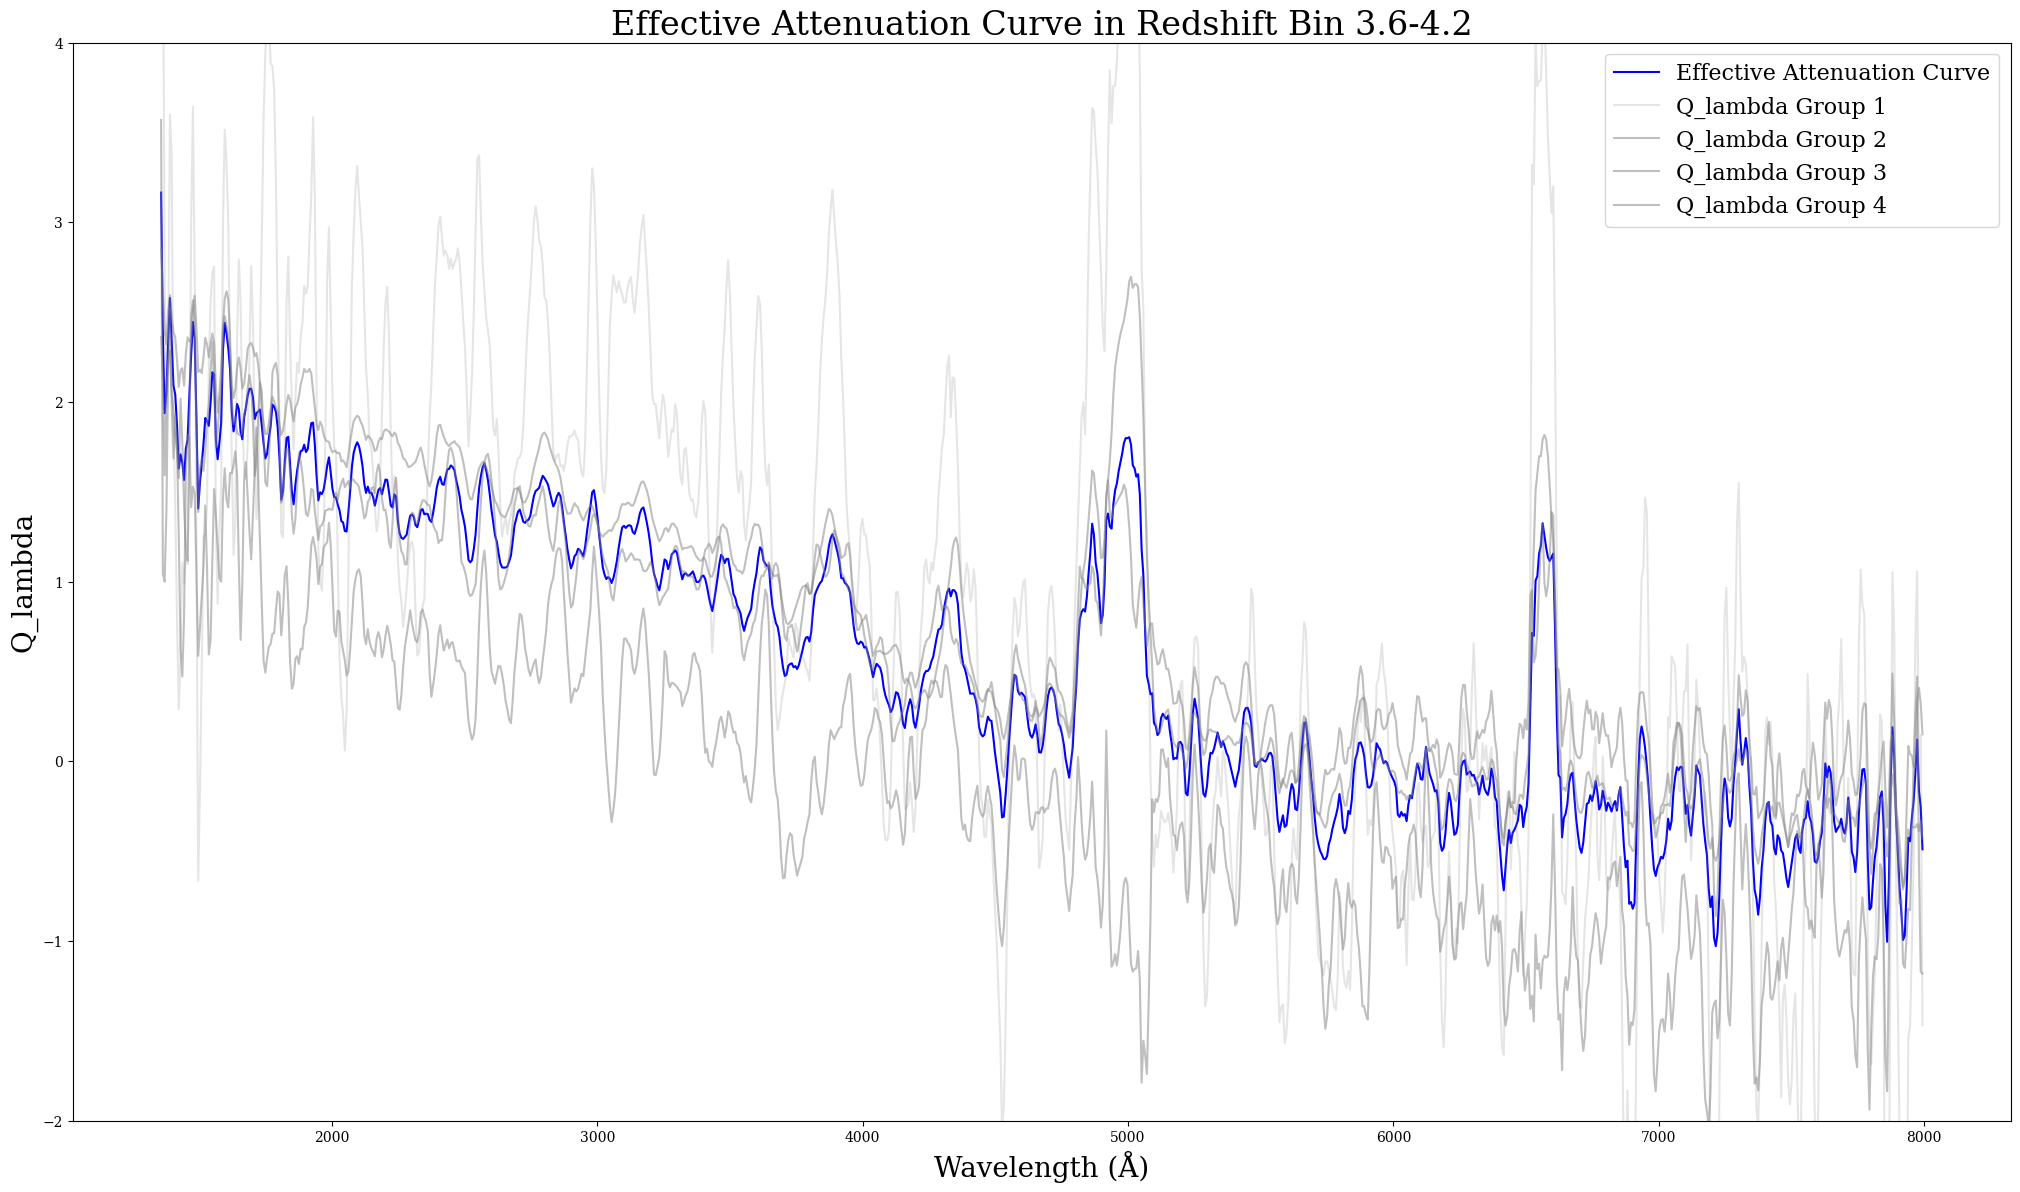

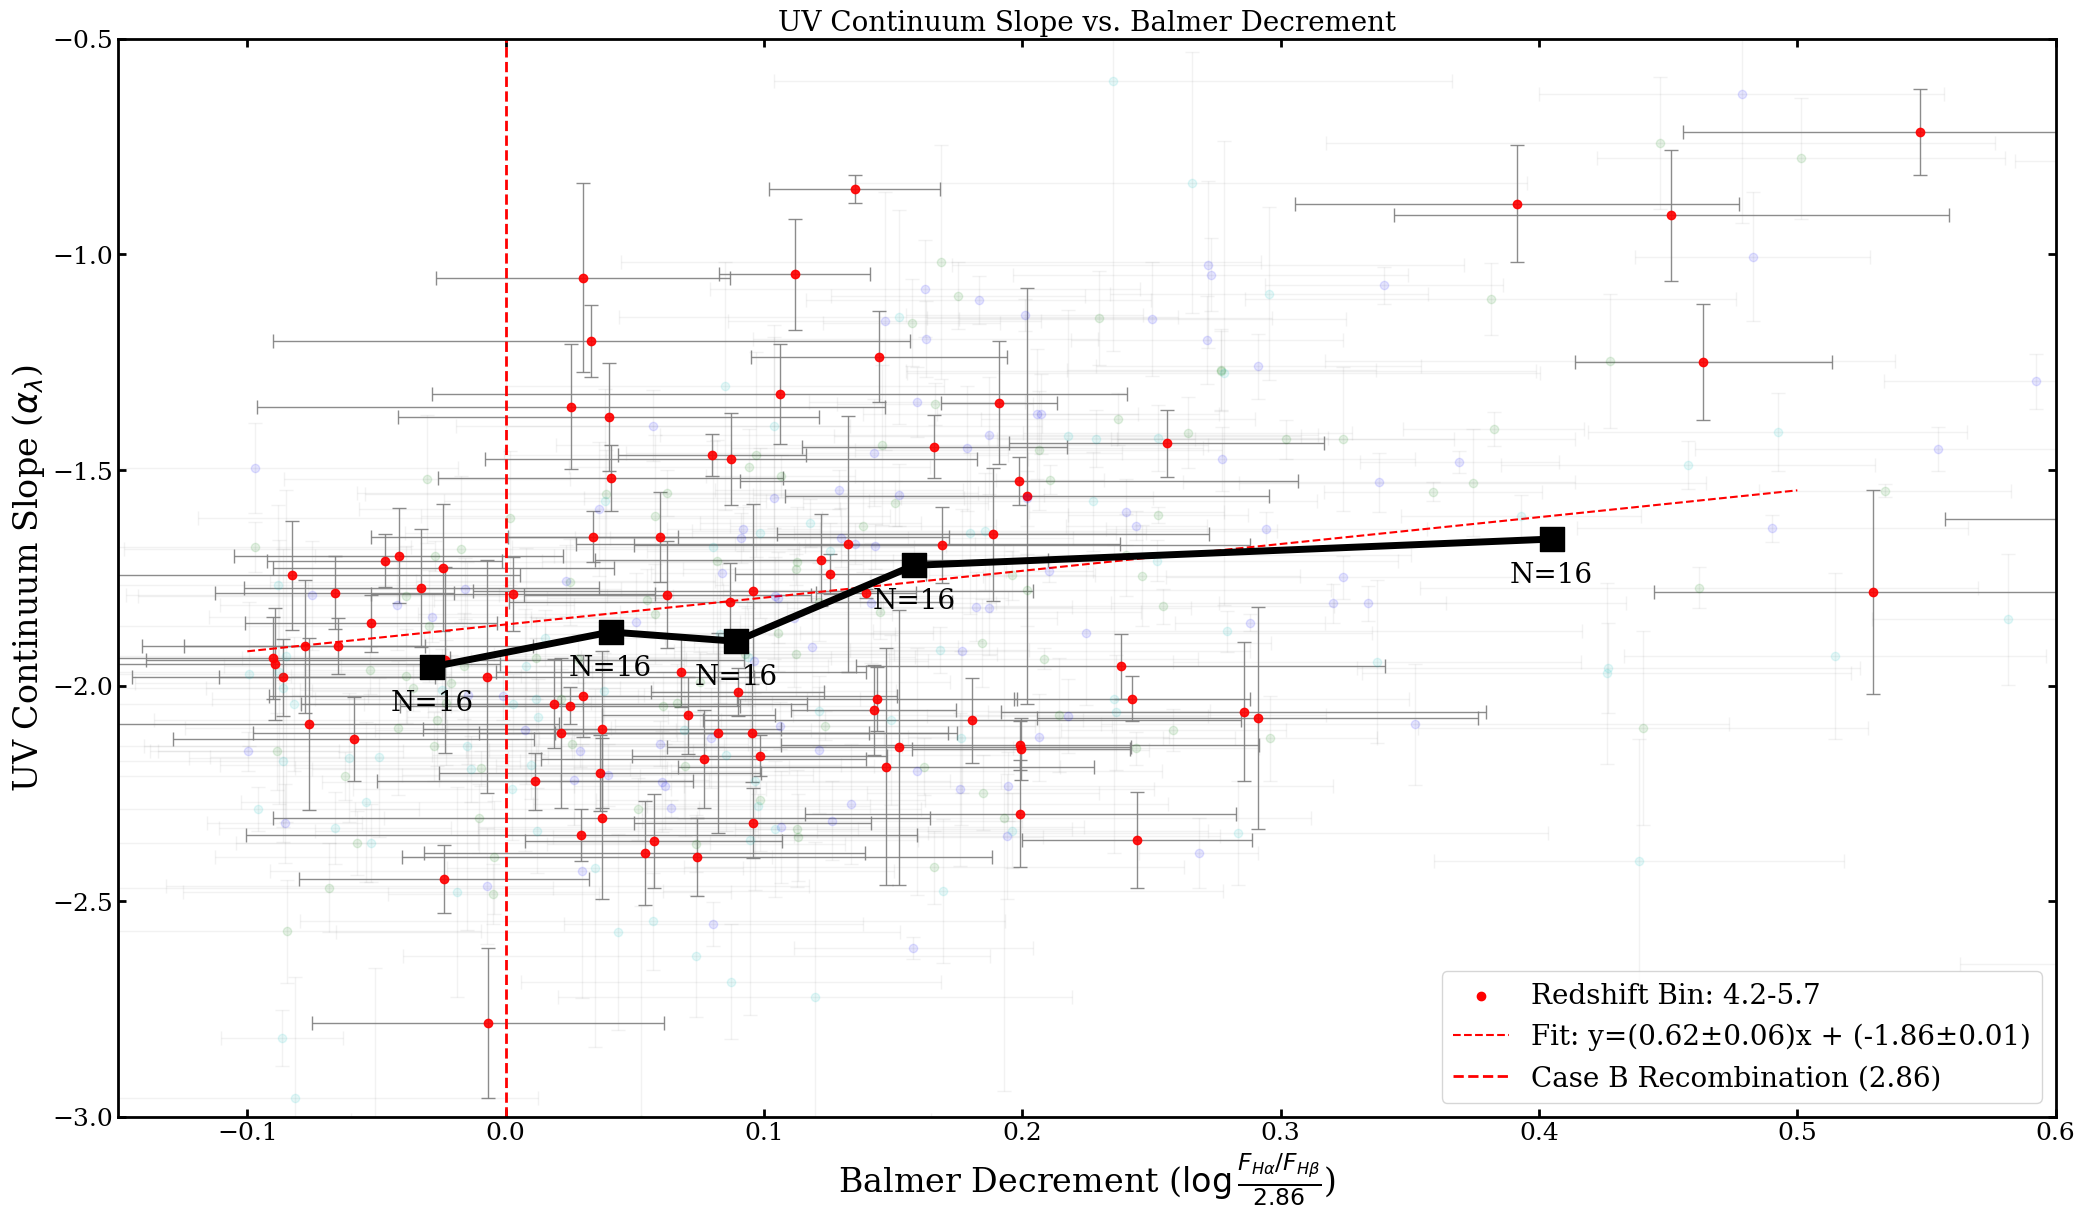

Processing Redshift Bin 4.2-5.7, Group 0, Number of Spectra: 16
Processing Redshift Bin 4.2-5.7, Group 1, Number of Spectra: 16
Processing Redshift Bin 4.2-5.7, Group 2, Number of Spectra: 16
Processing Redshift Bin 4.2-5.7, Group 3, Number of Spectra: 16
Processing Redshift Bin 4.2-5.7, Group 4, Number of Spectra: 16


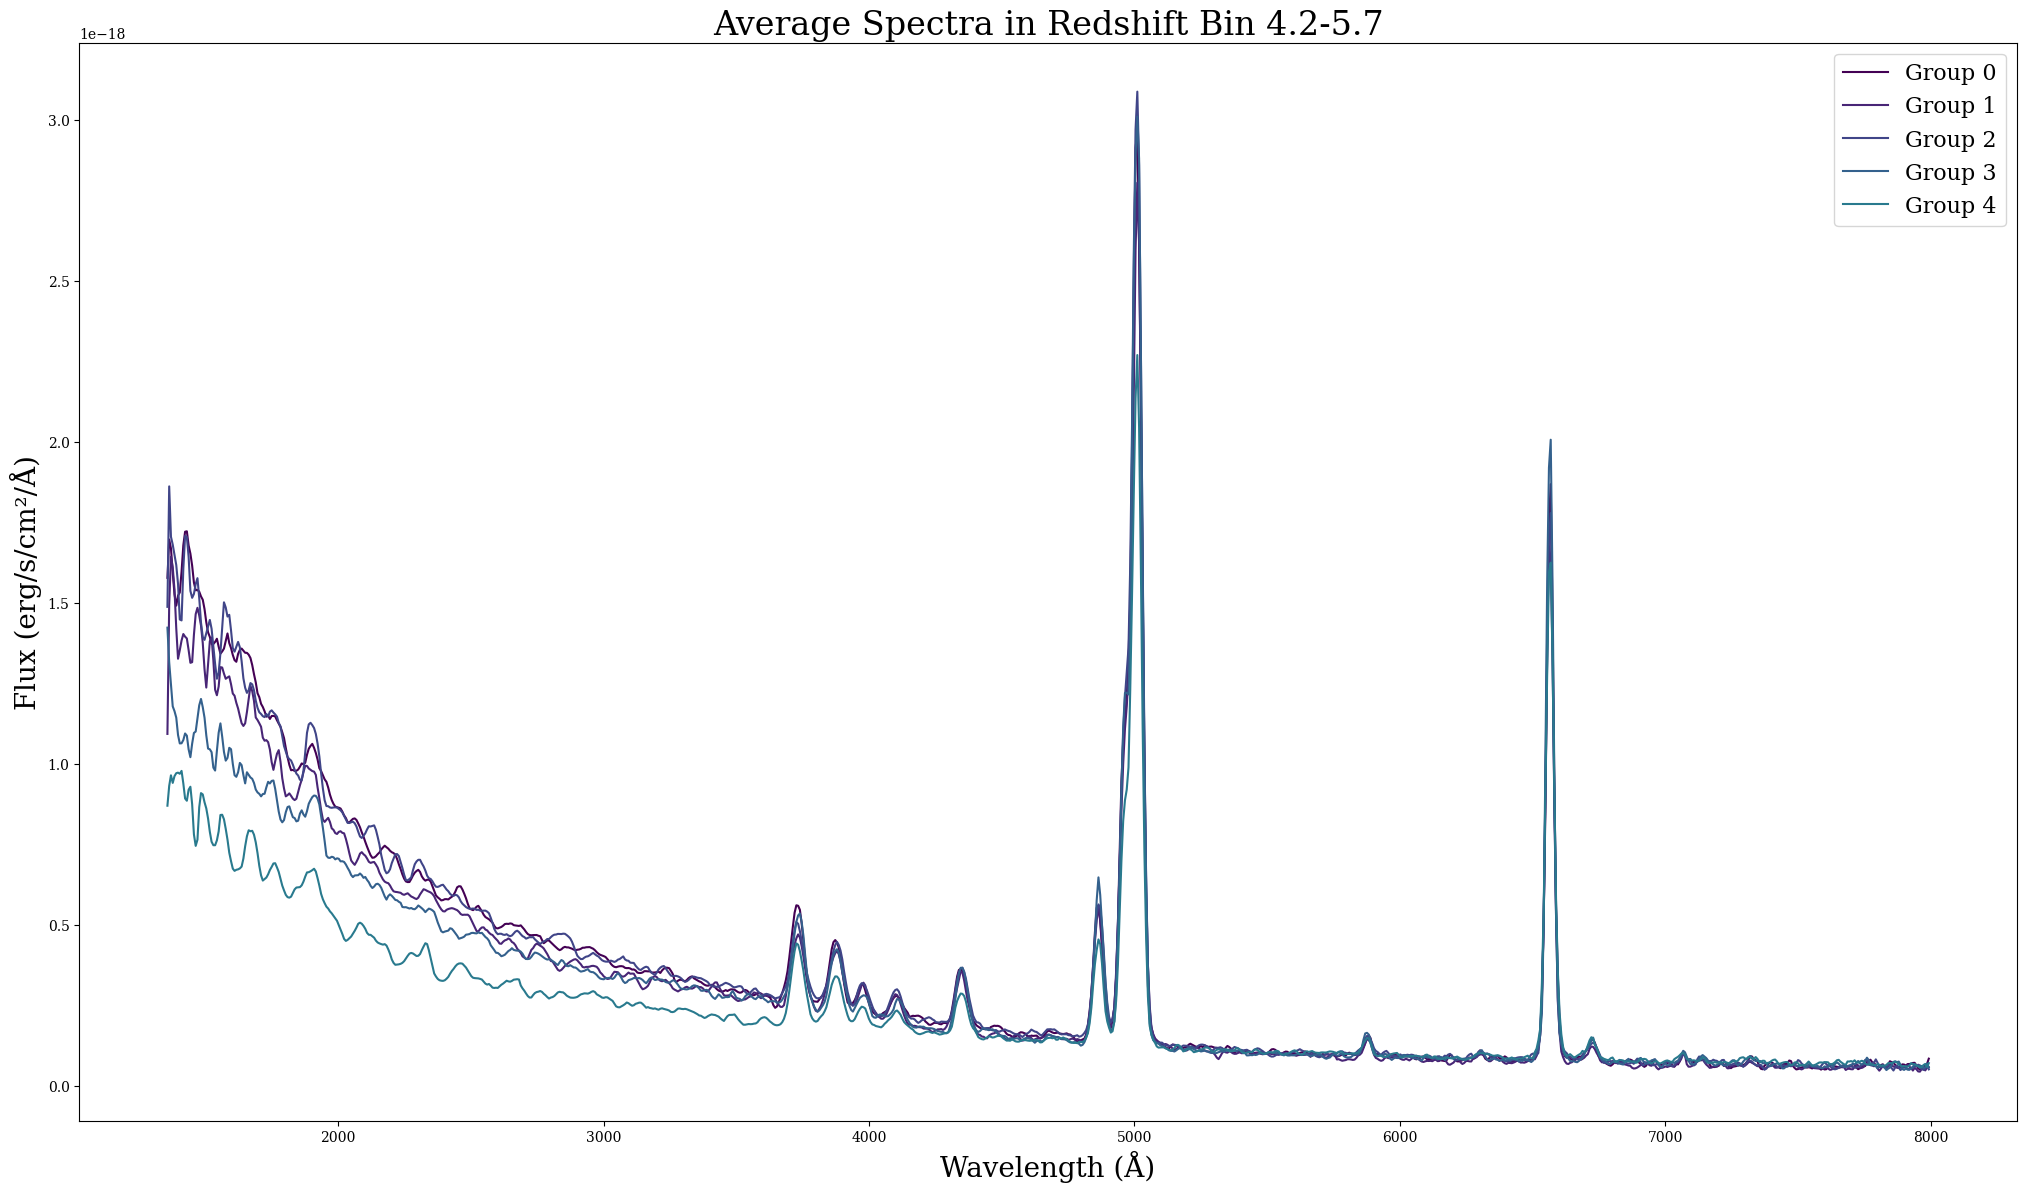

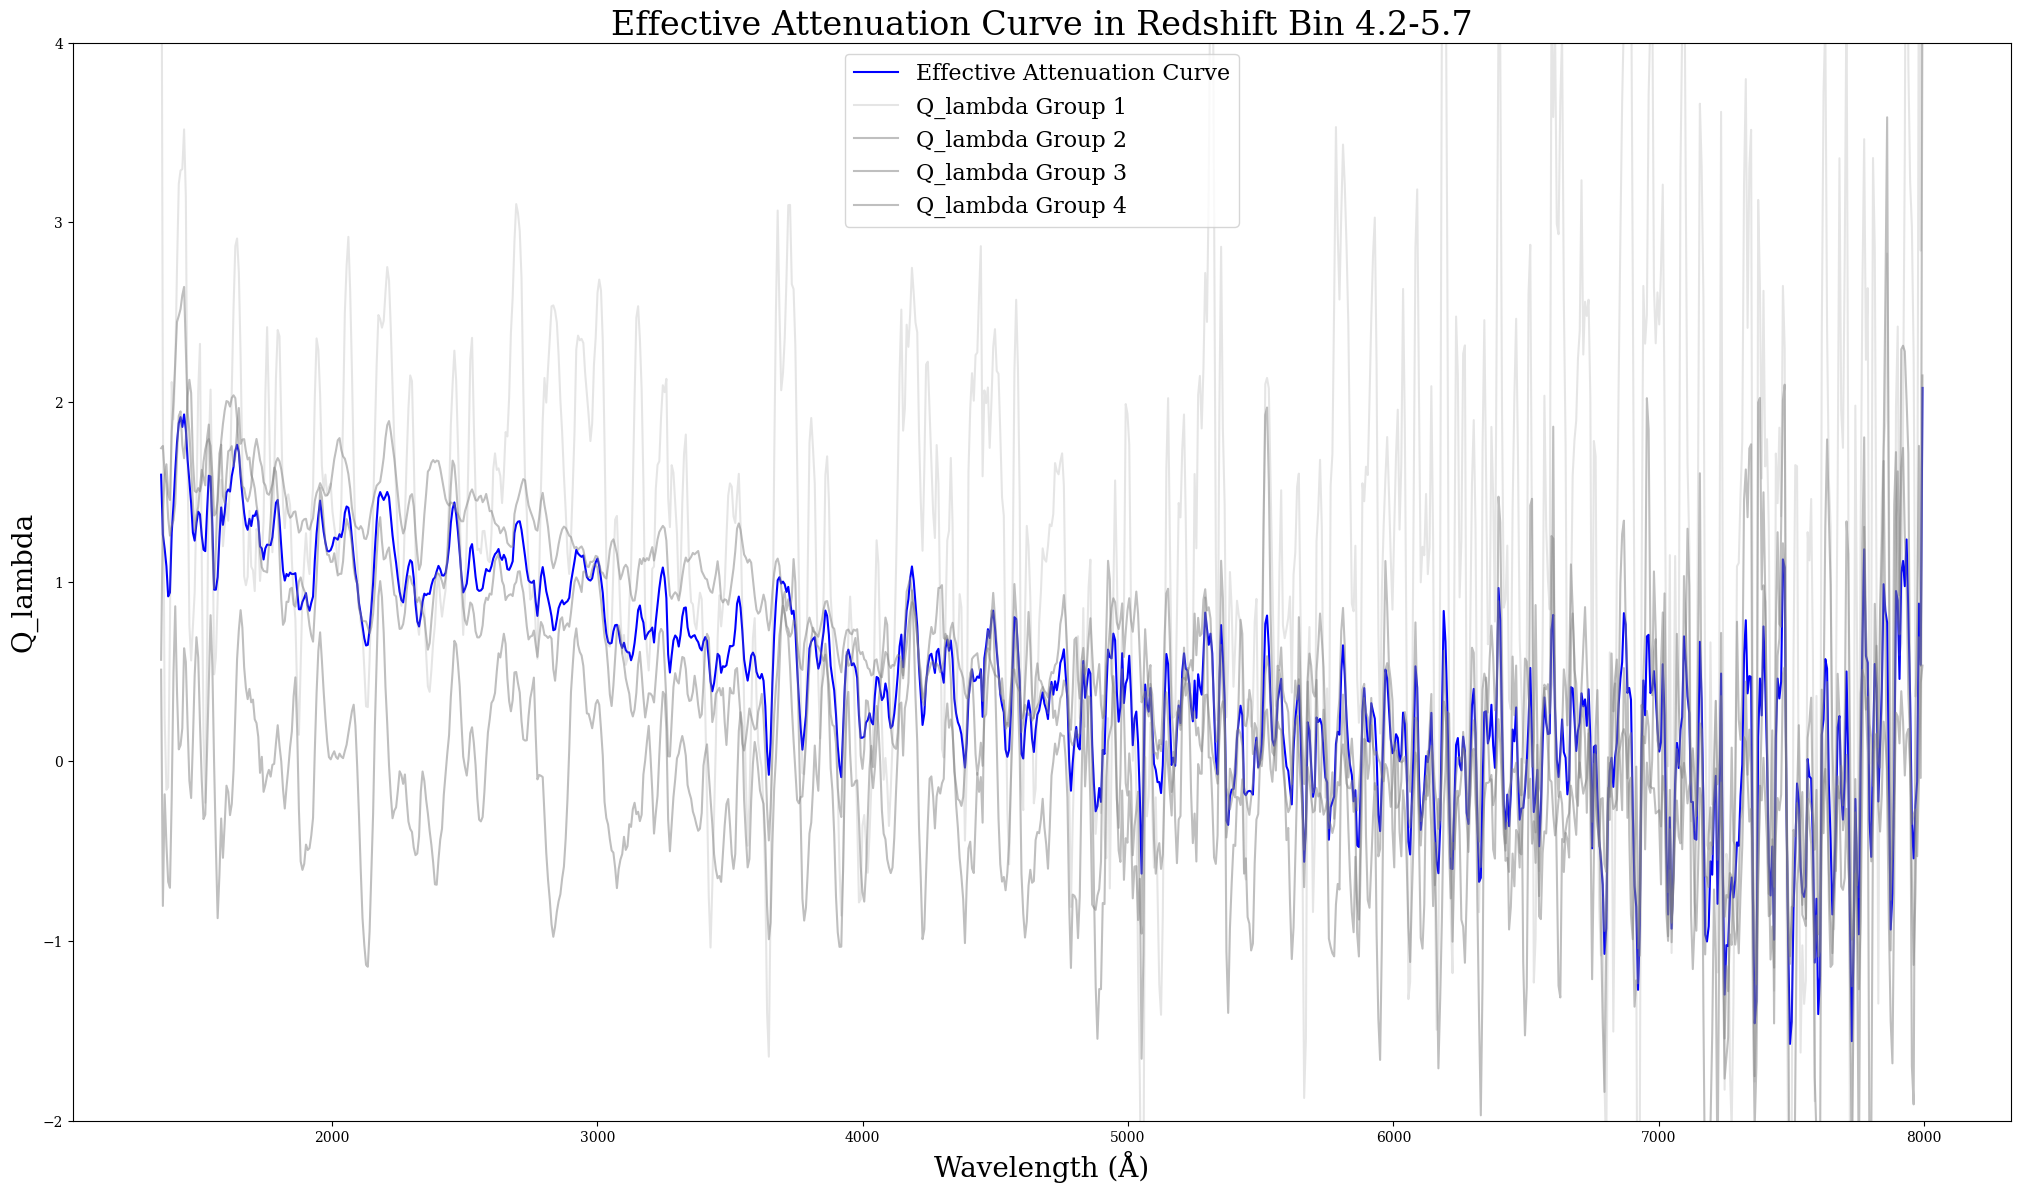

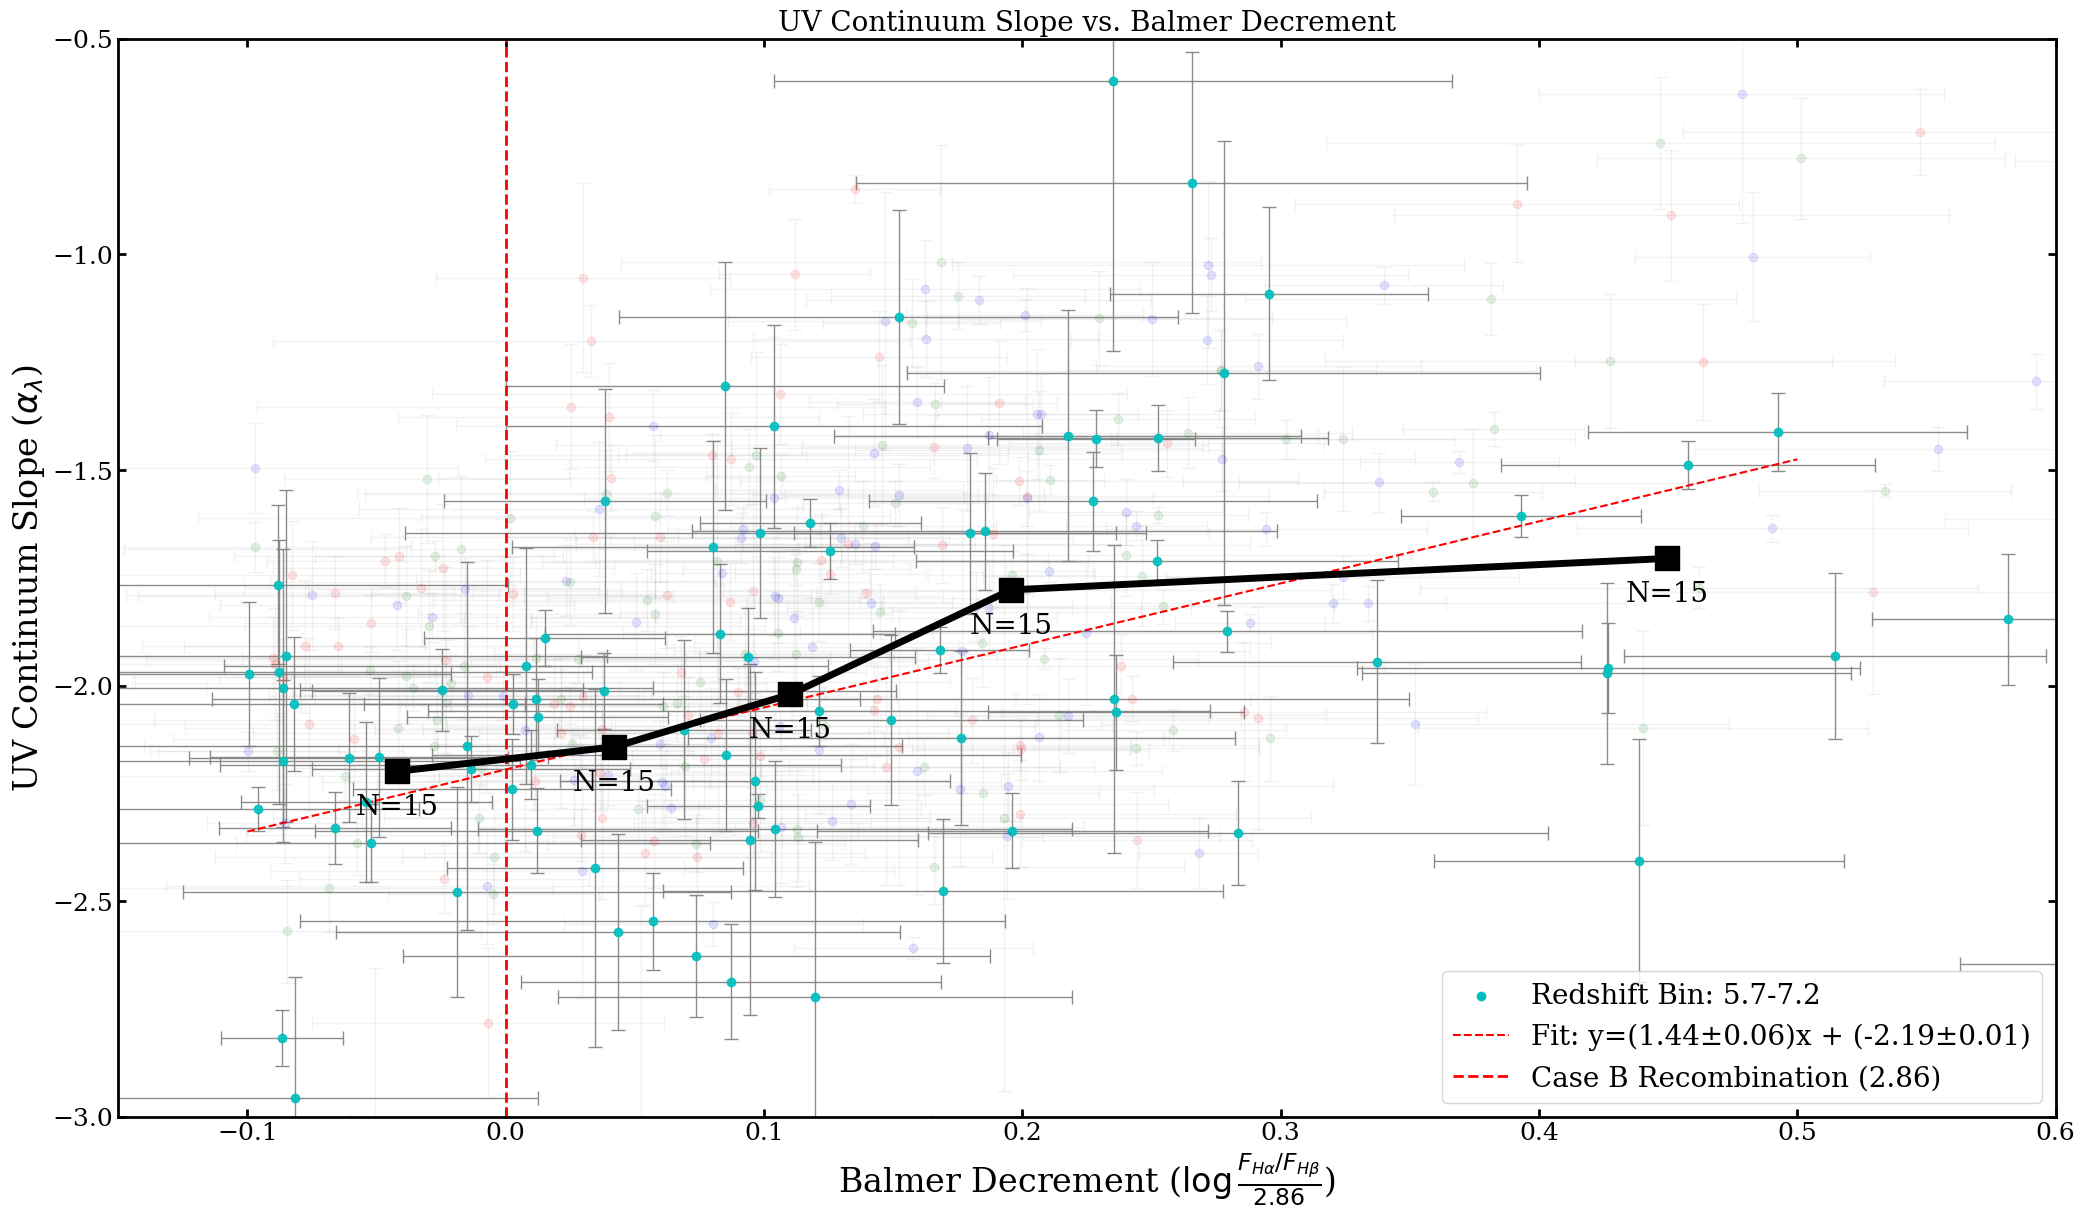

Processing Redshift Bin 5.7-7.2, Group 0, Number of Spectra: 15
Processing Redshift Bin 5.7-7.2, Group 1, Number of Spectra: 15
Processing Redshift Bin 5.7-7.2, Group 2, Number of Spectra: 15
Processing Redshift Bin 5.7-7.2, Group 3, Number of Spectra: 15
Processing Redshift Bin 5.7-7.2, Group 4, Number of Spectra: 15


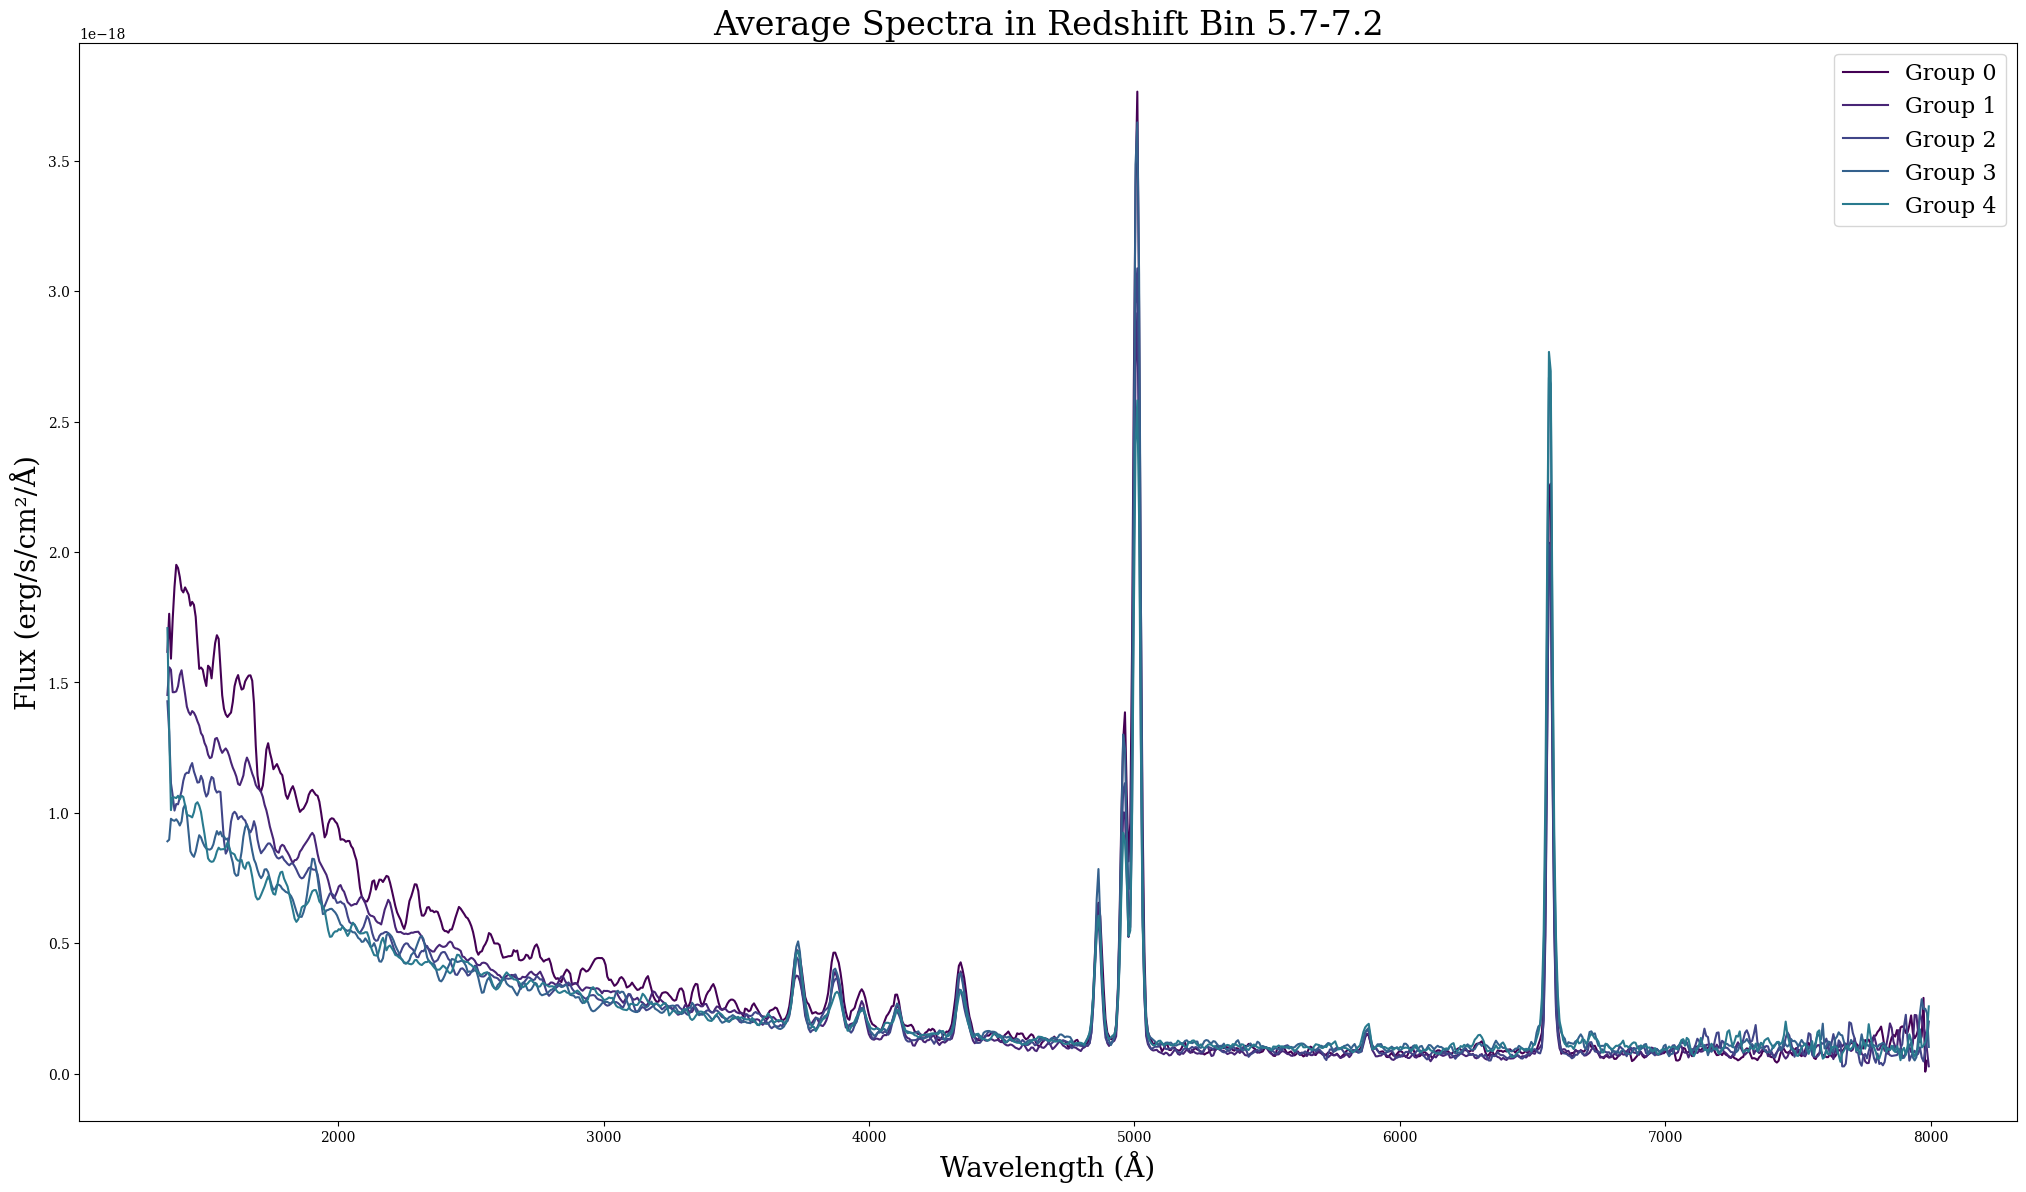

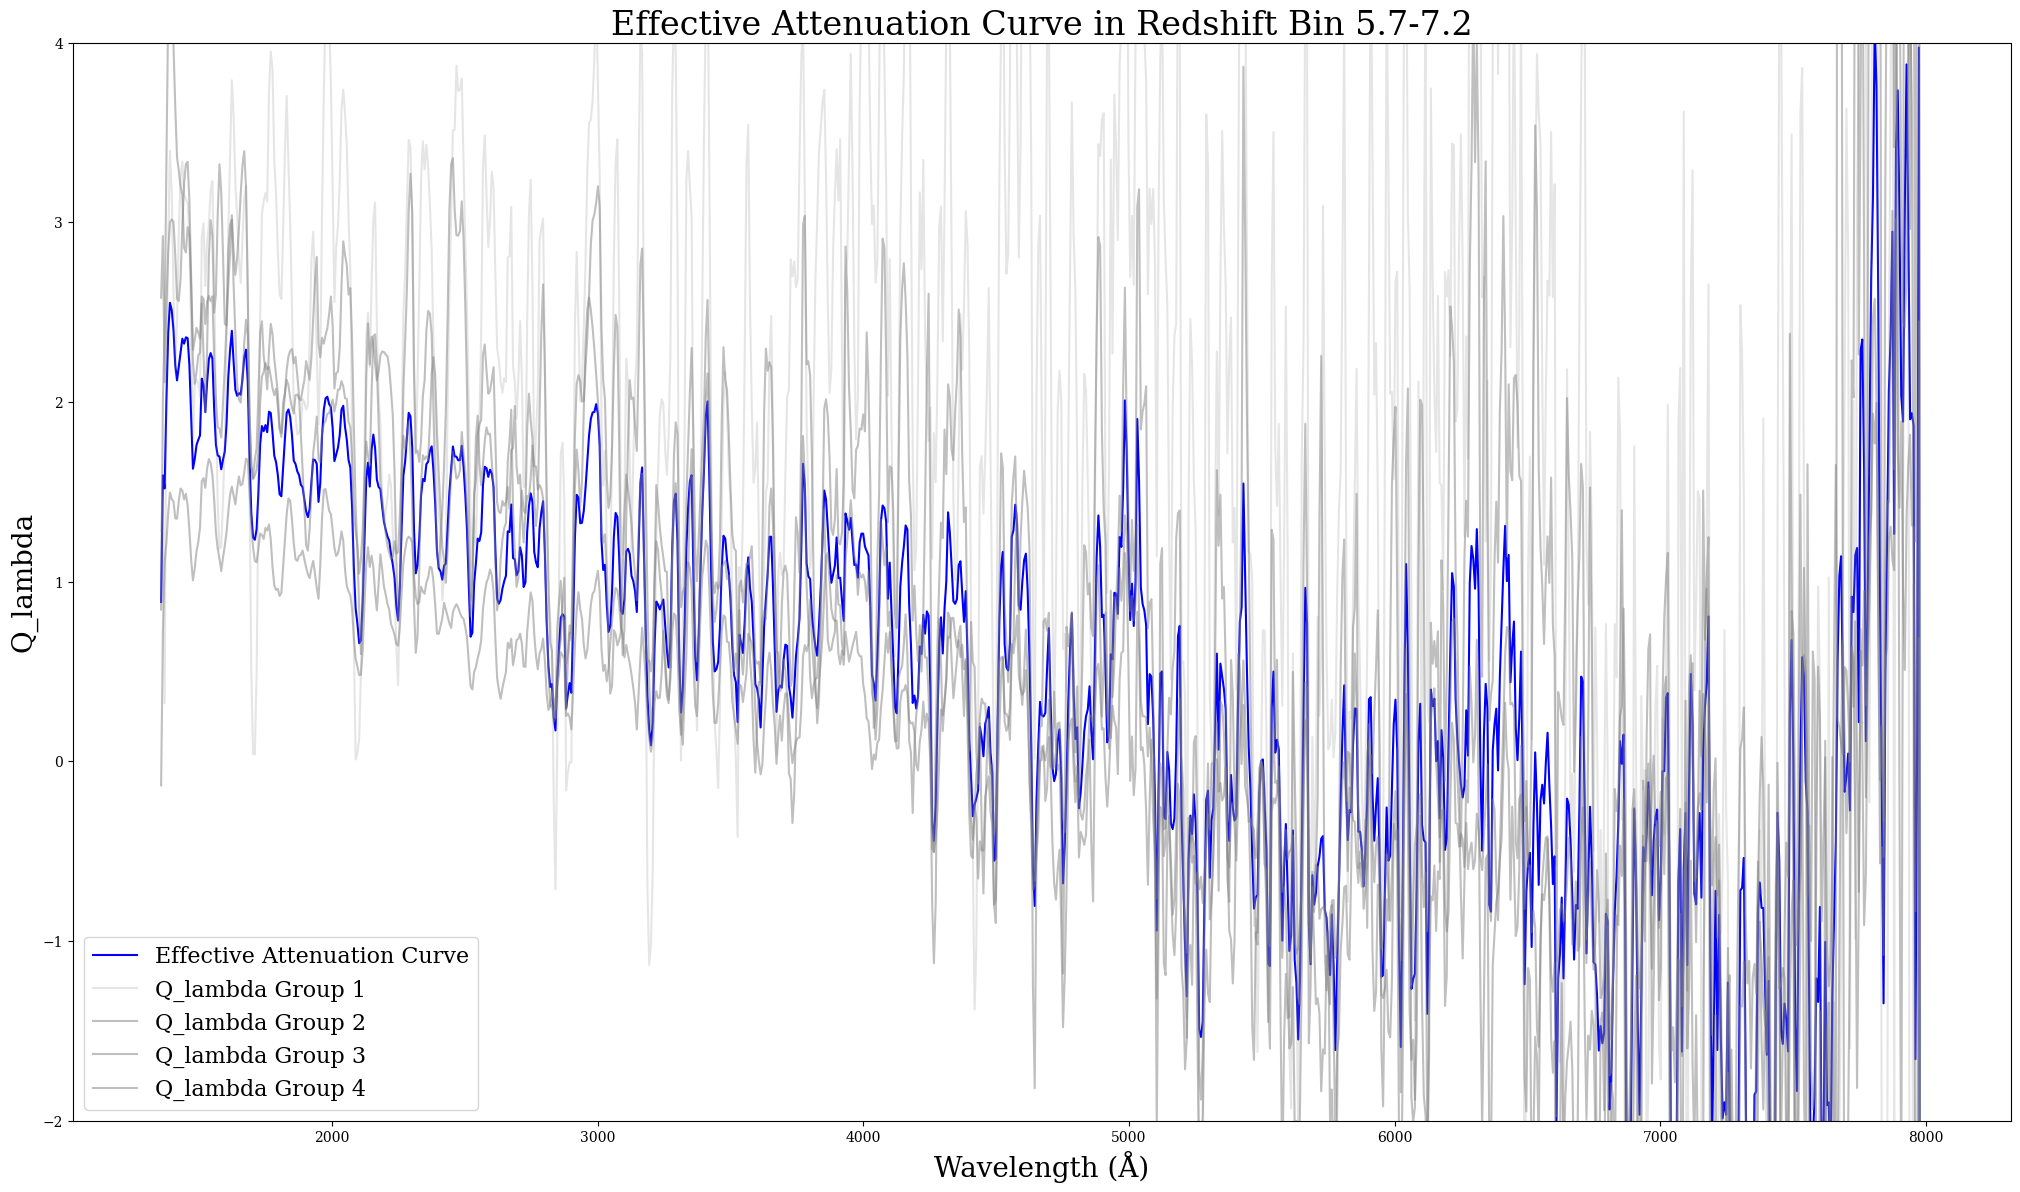

In [54]:
effective_attenuation_curve_list=[]

for redshift_bin_index in range(len(redshift_conditions)):
    fig, ax = plt.subplots(figsize=(25,14))
    ax.scatter([], [], color=color[redshift_bin_index], label=f'Redshift Bin: {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}')

    for i in range(len(uv_slope_array)):
        redshift_bin_id=redshift_condition_func(redshift_list[i])
        if redshift_bin_id != redshift_bin_index:
            alpha=0.1
        else:
            alpha=0.9
        ax.errorbar(balmer_decrement_array[i], uv_slope_array[i], xerr=balmer_decrement_uncertainty_array[i], yerr=uv_slope_err_array[i], fmt='o', color=colors_list[i], alpha=alpha, ecolor='gray', elinewidth=1, capsize=5)
    # Fit linear function
    mask = (redshift_list >= redshift_conditions[redshift_bin_index][0]) & (redshift_list < redshift_conditions[redshift_bin_index][1])
    popt, pcov = curve_fit(linear_func, balmer_decrement_array[mask], uv_slope_array[mask], sigma=uv_slope_err_array[mask], absolute_sigma=True)
    x_fit = np.linspace(-0.1, 0.5, 100)
    y_fit = linear_func(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r--', label=f'Fit: y=({popt[0]:.2f}±{np.sqrt(pcov[0,0]):.2f})x + ({popt[1]:.2f}±{np.sqrt(pcov[1,1]):.2f})')

    ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
    ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
    ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
    ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
    ax.set_xlim(-0.15,0.6)
    ax.set_ylim(-3,-0.5)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
    ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
    ax.xaxis.set_tick_params(length=6, which='major')
    ax.xaxis.set_tick_params(length=3, which='minor')
    ax.yaxis.set_tick_params(length=6, which='major')
    ax.yaxis.set_tick_params(length=3, which='minor')
    ax.legend(fontsize=20, loc='best')


    group_boundaries=[np.percentile(balmer_decrement_array[(redshift_list>=redshift_conditions[redshift_bin_index][0]) & (redshift_list<redshift_conditions[redshift_bin_index][1])], [5,23,41,59,77,95])]
    group_conditions=[[group_boundaries[0][i], group_boundaries[0][i+1]] for i in range(len(group_boundaries[0])-1)]

    last_point_x=None
    last_point_y=None
    for lower, upper in group_conditions:
        group_mask = (balmer_decrement_array[(redshift_list>=redshift_conditions[redshift_bin_index][0]) & (redshift_list<redshift_conditions[redshift_bin_index][1])] >= lower) & (balmer_decrement_array[(redshift_list>=redshift_conditions[redshift_bin_index][0]) & (redshift_list<redshift_conditions[redshift_bin_index][1])] < upper)
        group_num = np.sum(group_mask)
        if np.sum(group_mask) == 0:
            continue
        group_uv_slopes = uv_slope_array[(redshift_list>=redshift_conditions[redshift_bin_index][0]) & (redshift_list<redshift_conditions[redshift_bin_index][1])][group_mask]
        group_uv_slope_errs = uv_slope_err_array[(redshift_list>=redshift_conditions[redshift_bin_index][0]) & (redshift_list<redshift_conditions[redshift_bin_index][1])][group_mask]

        lower_value=5
        upper_value=100-lower_value


        mask_lower_16_upper_84 = (group_uv_slopes >= np.percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= np.percentile(group_uv_slopes, upper_value))
        group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


        weighted_mean_uv_slope = np.average(group_uv_slopes)

        mid_point = (lower + upper) / 2
        z=30

        ax.scatter(mid_point, weighted_mean_uv_slope,
                    marker='s', color='black', s=288,
                    label=f'Bin [{lower:.2f}, {upper:.2f}] Mean' if lower == group_conditions[0][0] else "", zorder=z)
        if last_point_x is not None and last_point_y is not None:
            ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
        last_point_x = mid_point
        last_point_y = weighted_mean_uv_slope

        plt.text(mid_point, weighted_mean_uv_slope-0.1, f'N={group_num}', fontsize=20, ha='center',zorder=z,c='black')

    plt.show()

    num_balmer_decrement_bins=len(group_conditions)

    for i in range(num_balmer_decrement_bins):
        globals()['group'+str(i)+'_averager']=FL.SpectrumAverager()

    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue
        redshift_bin_id=redshift_condition_func(catalog['determined_redshift'])
        if redshift_bin_id != redshift_bin_index:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement, group_conditions)
        if group_index is None:
            continue

        averager_to_use='group'+str(group_index)+'_averager'
        globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

    for i in range(len(group_conditions)):
        averager_to_use='group'+str(i)+'_averager'
        print(f'Processing Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}, Group {i}, Number of Spectra: {len(globals()[averager_to_use].spectra_data)}')


    for i in range(len(group_conditions)):
        averager_to_use='group'+str(i)+'_averager'
        globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000))
        globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
        globals()[averager_to_use].spectrum_normalization(reference_wavelength=5500.0, target_flux=1e-19)
        globals()[averager_to_use].spectrum_normalization()
        globals()[averager_to_use].compute_average_spectrum(method='mean', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
        # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)


    group_decrement_list=[]

    for i in range(len(group_conditions)):
        decrement_list=[]

        for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
            if not catalog['sample_flag']:
                continue

            uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
            halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
            hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
            balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
            group_index=group_condition_func(balmer_decrement, group_conditions)
            if group_index!=i:
                continue
            # if group_index==0:
            #     continue

            decrement_list.append(balmer_decrement)

        group_decrement_list.append(np.nanmean(decrement_list))

    model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
    tau_lambda_list=[]
    Q_lambda_list=[]

    for i in range(1,len(group_conditions)):
        averager_to_use='group'+str(i)+'_averager'
        tau_lambda_list=[]
        groupi_averager=globals()[averager_to_use]
        tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
        tau_lambda_list.append(tau_lambda)
        Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
        Q_lambda_list.append(Q_lambda)

    fig, ax=plt.subplots(figsize=(25,14))
    colors=plt.cm.viridis(np.linspace(0, num_balmer_decrement_bins))
    for i in range(num_balmer_decrement_bins):
        averager_to_use='group'+str(i)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
    ax.set_xlabel('Wavelength (Å)', fontsize=20)
    ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=20)
    ax.set_title(f'Average Spectra in Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    plt.show()


    Q_lambda_array=np.array(Q_lambda_list)

    weighting_factors=[]
    for i in range(1, len(group_conditions)):
        weighting_factors.append(group_decrement_list[i]-group_decrement_list[0])

    effective_attenuation_curve=np.average(Q_lambda_array, axis=0, weights=weighting_factors)
    fig, ax=plt.subplots(figsize=(25,14))
    averager=group1_averager
    ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
    for i in range(0,len(group_conditions)-1):
        Q_lambda=Q_lambda_list[i]
        averager_to_use='group'+str(i+1)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))
    plt.xlabel('Wavelength (Å)', fontsize=20)
    plt.ylabel('Q_lambda', fontsize=20)
    plt.ylim(-2,4)
    plt.title('Effective Attenuation Curve in Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', fontsize=24)
    plt.legend(fontsize=16)
    plt.show()
    effective_attenuation_curve_list.append((averager.common_wavelength, effective_attenuation_curve))


In [44]:
wavelength_smoothed=np.linspace(1350,8000,(8000-1350)//50+1)
for i in range(len(effective_attenuation_curve_list)):
    wavelength, Q_lambda=effective_attenuation_curve_list[i]
    Q_lambda_smoothed=np.interp(wavelength_smoothed, wavelength, Q_lambda)
    effective_attenuation_curve_list[i]=(wavelength_smoothed, Q_lambda_smoothed)

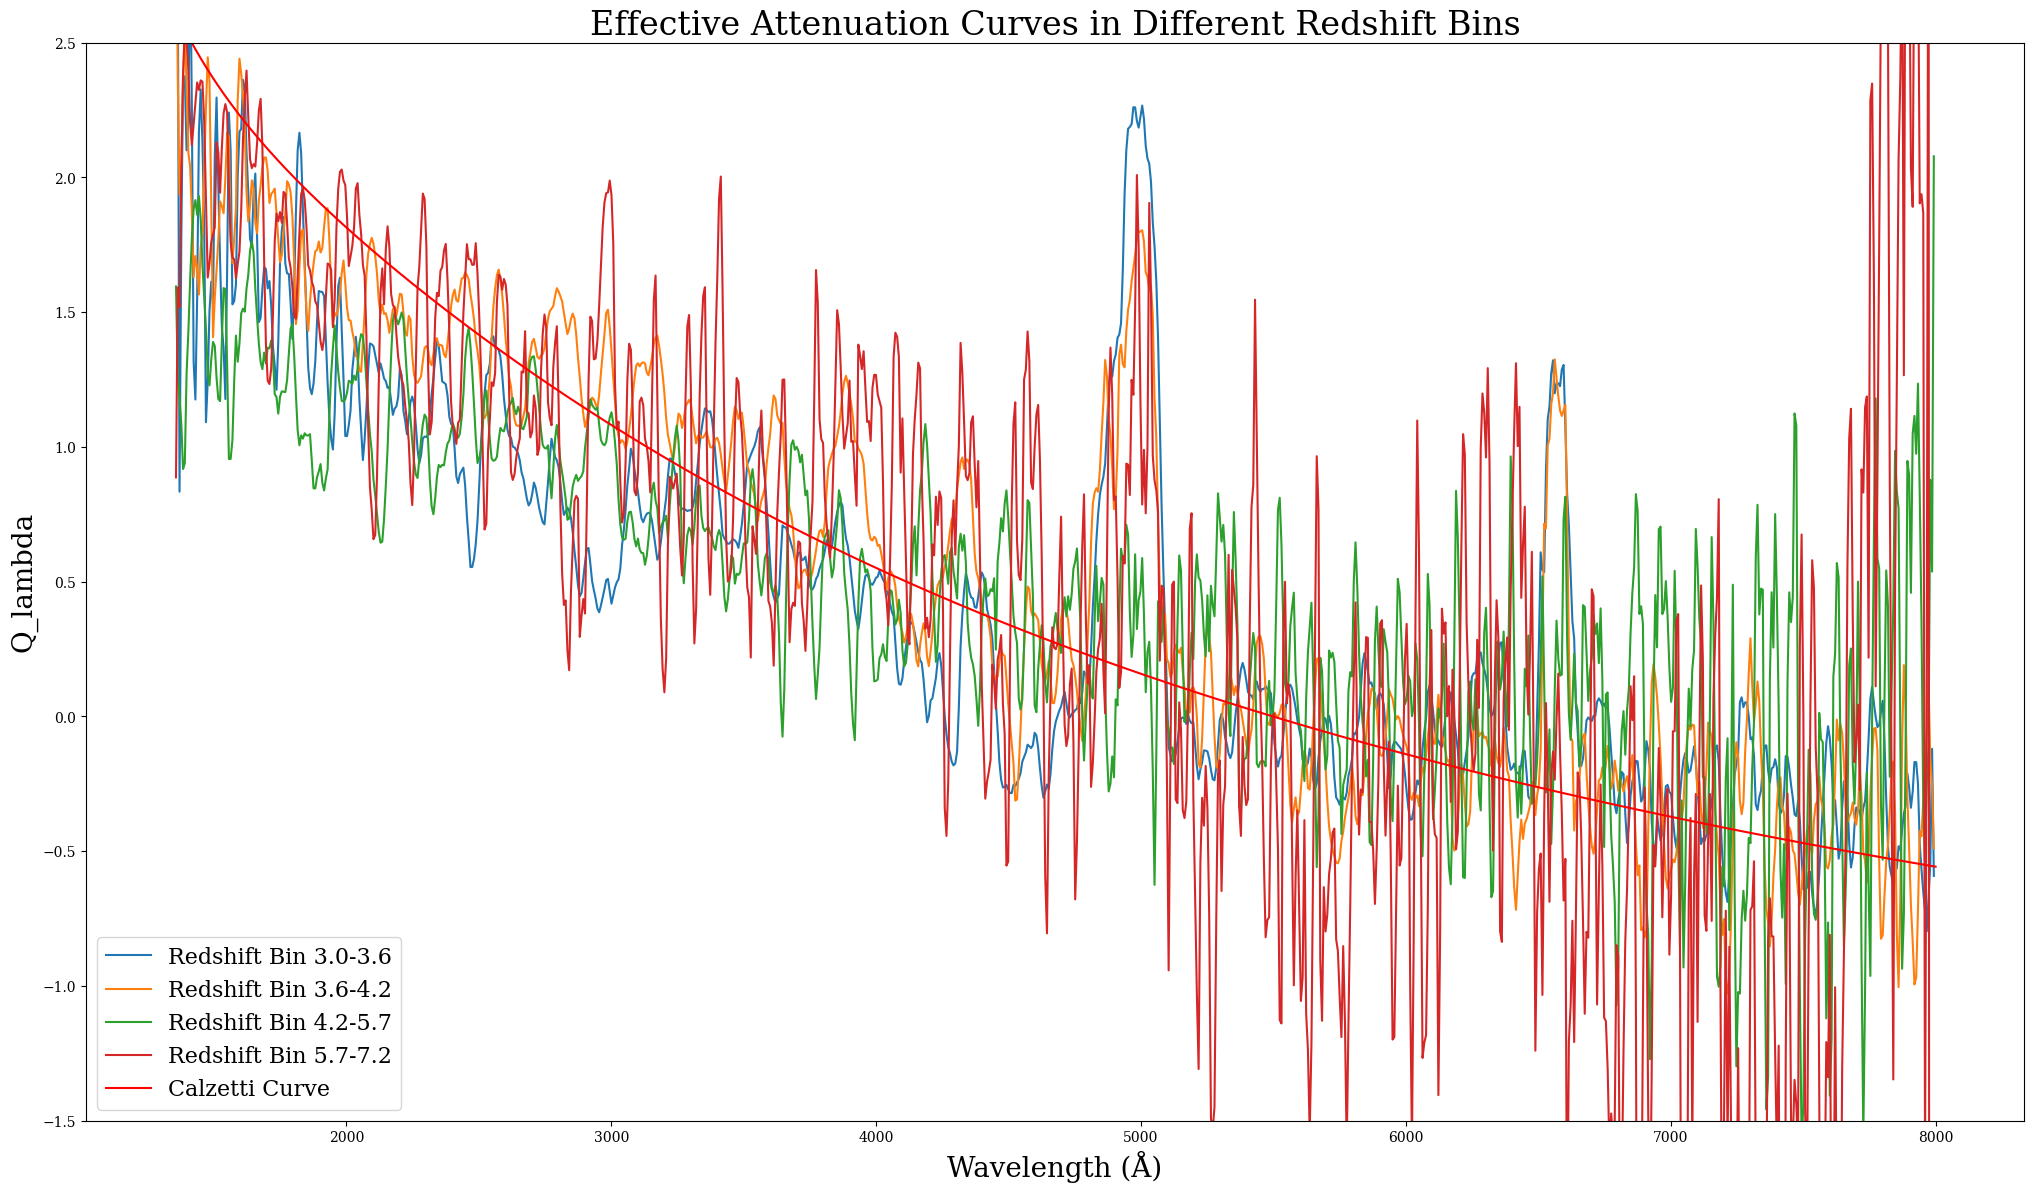

In [55]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

#use sns color palette

colors=sns.color_palette( n_colors=len(redshift_conditions))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))
for redshift_bin_index in range(len(redshift_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[redshift_bin_index]
    ax.plot(common_wavelength, effective_attenuation_curve, label='Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', color=colors[redshift_bin_index])

ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Redshift Bins', fontsize=24)
plt.legend(fontsize=16)
plt.ylim(-1.5,2.5)
plt.show()

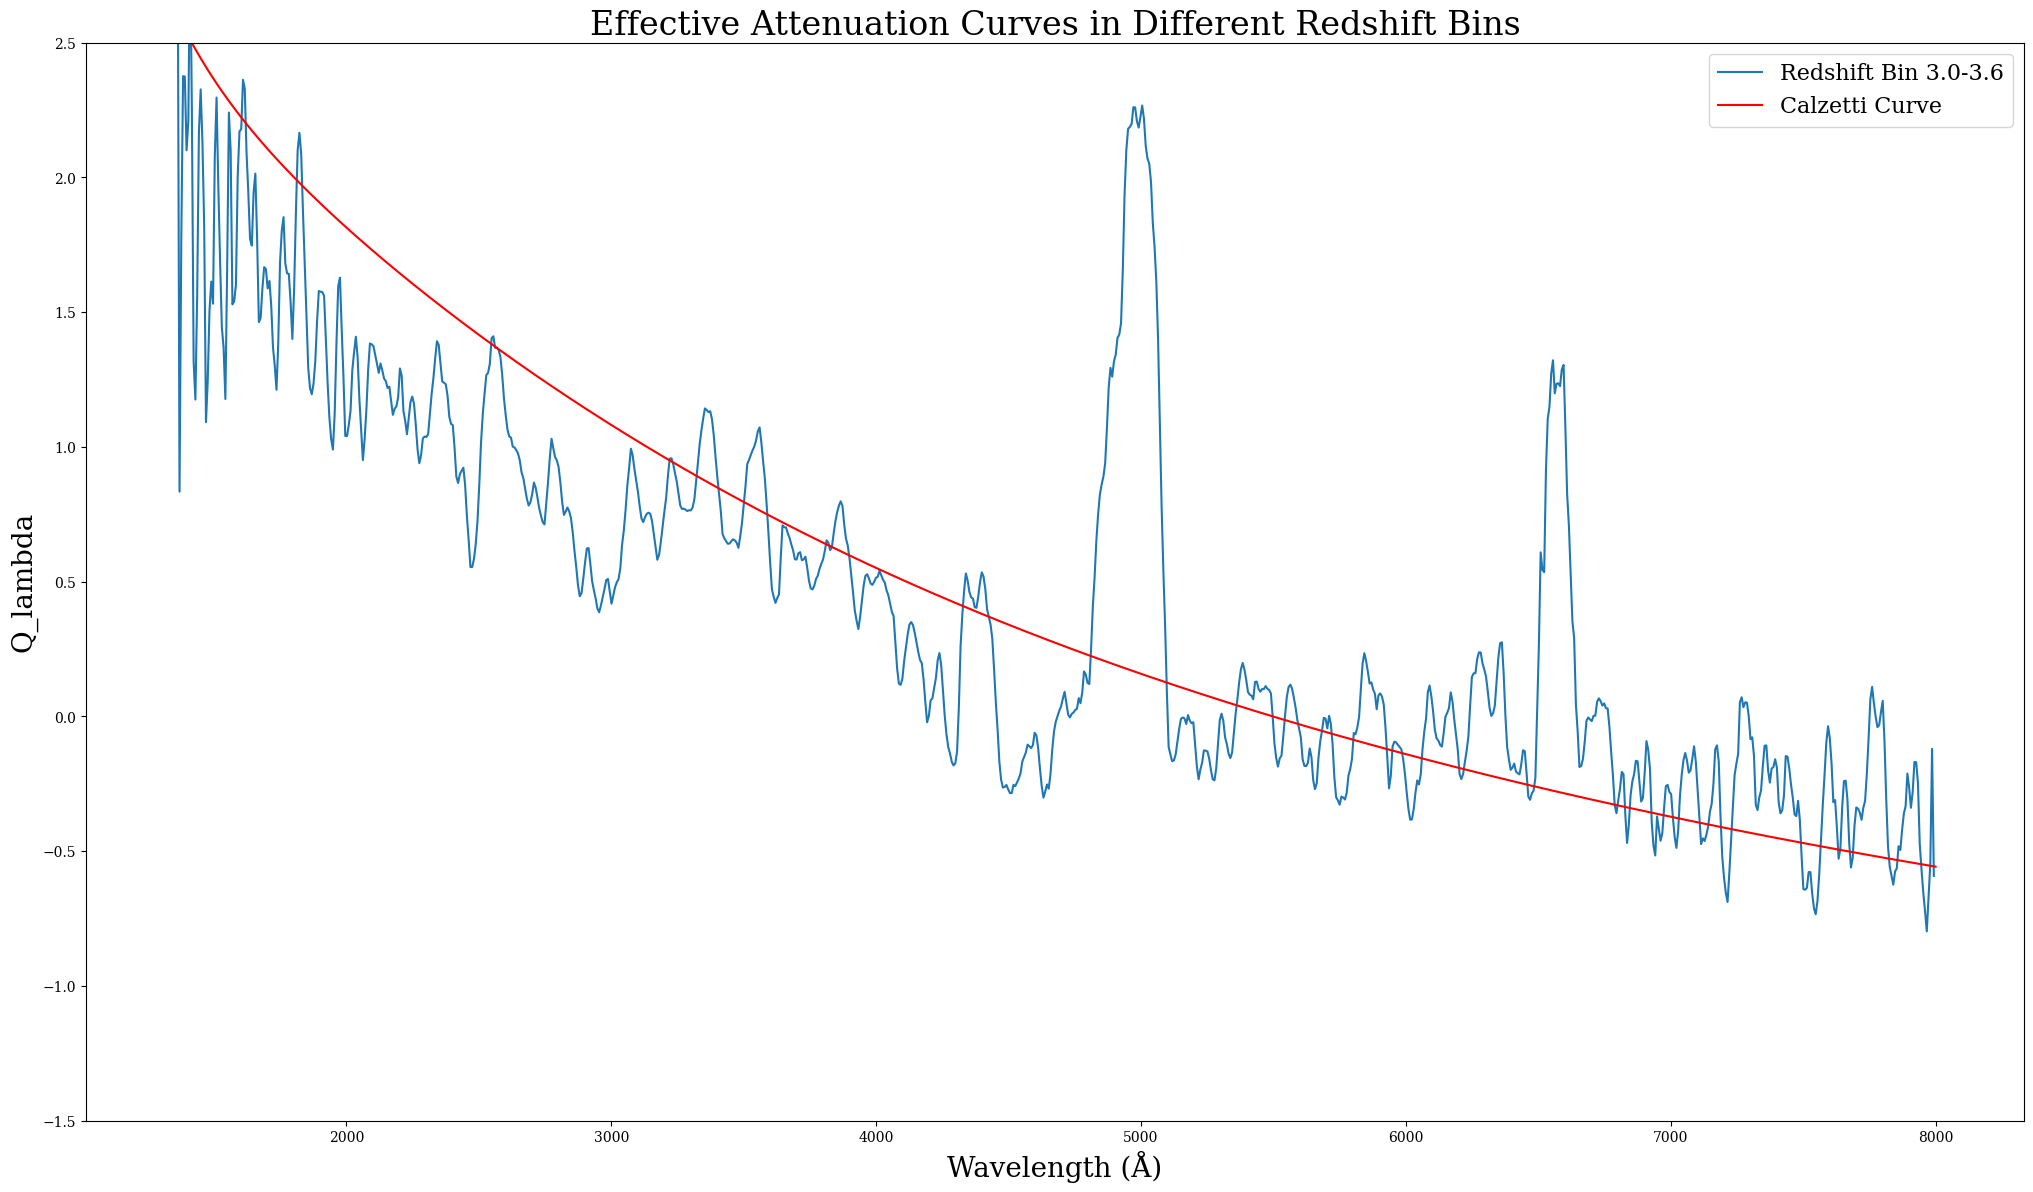

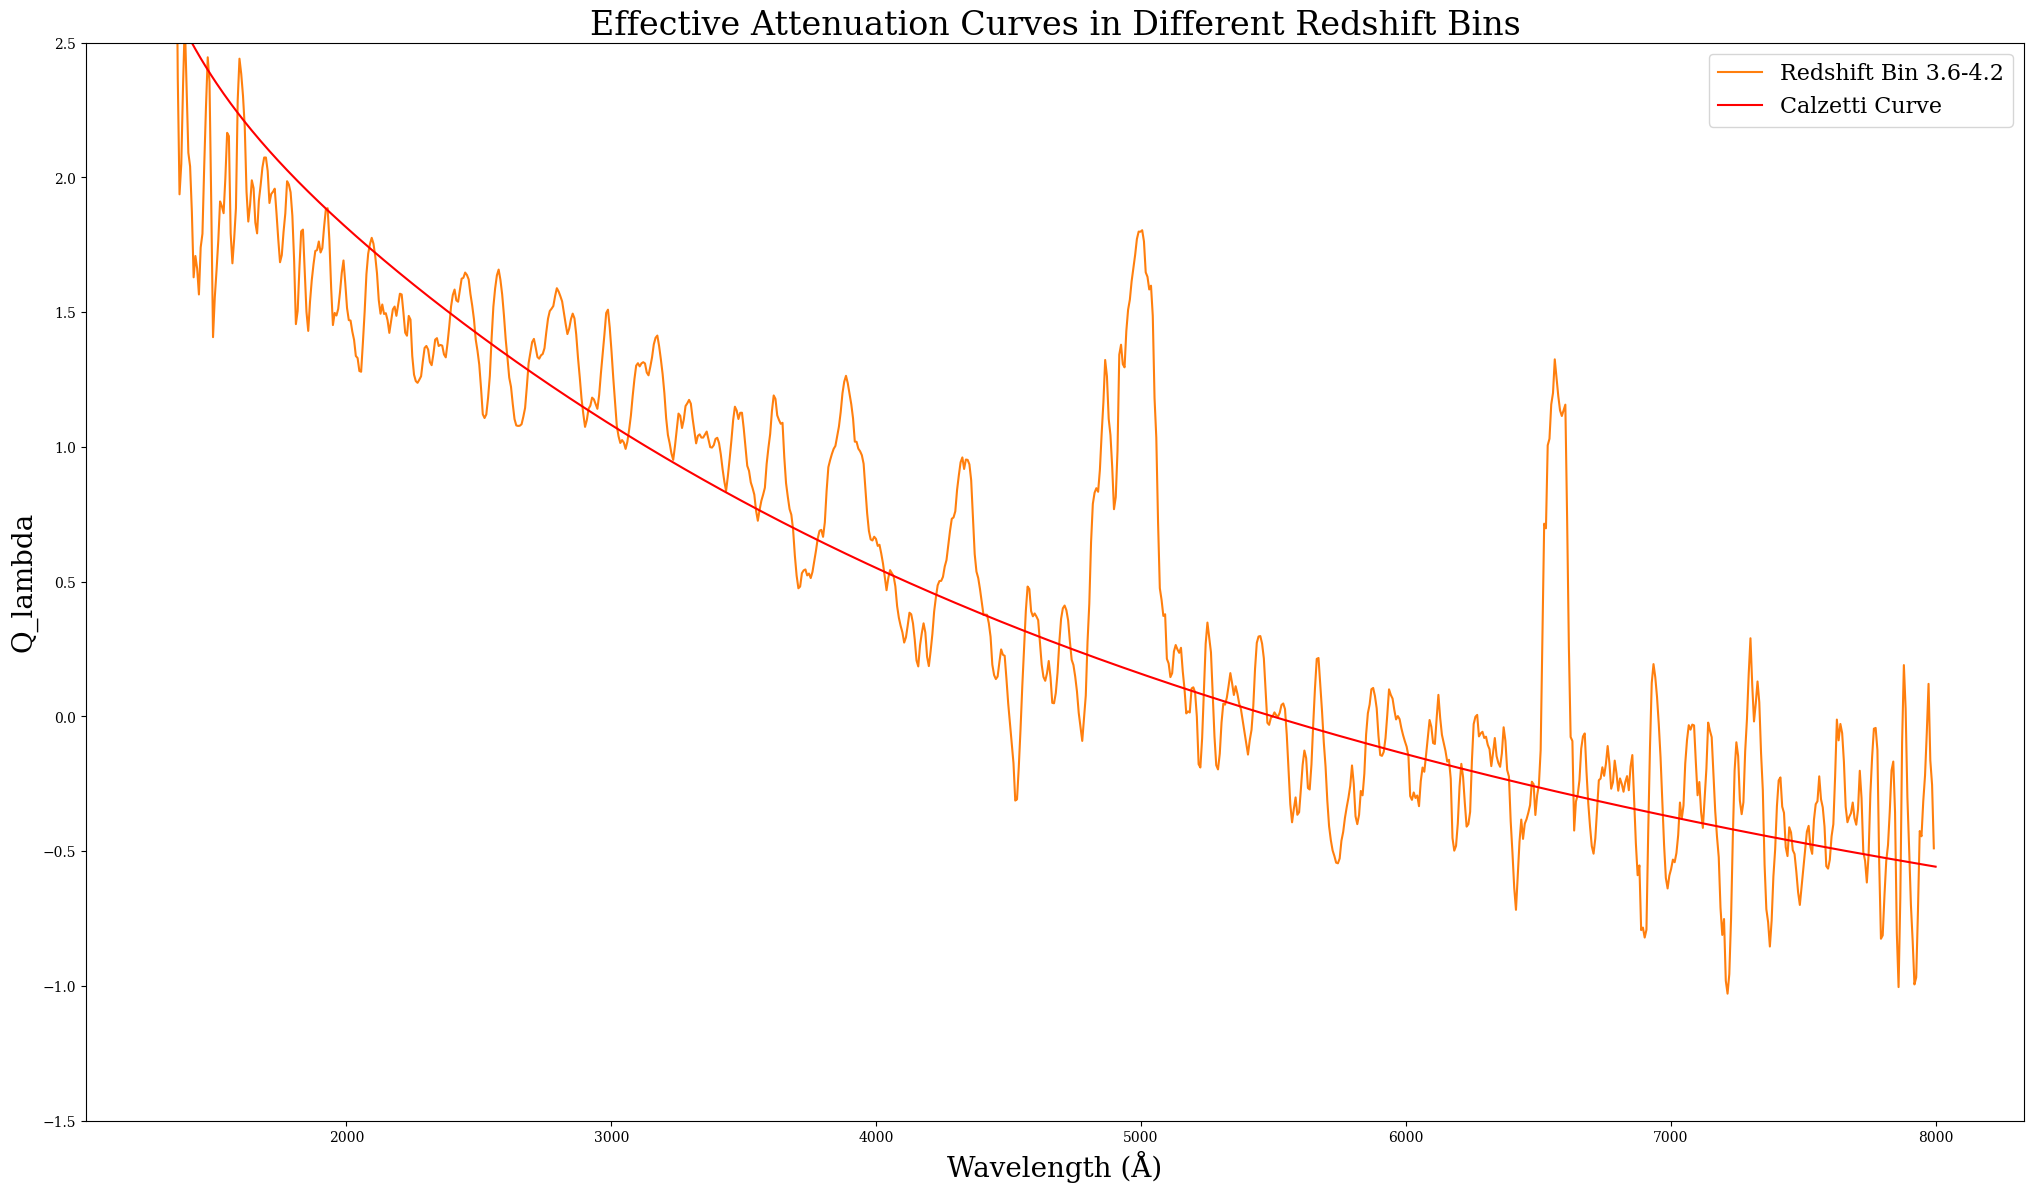

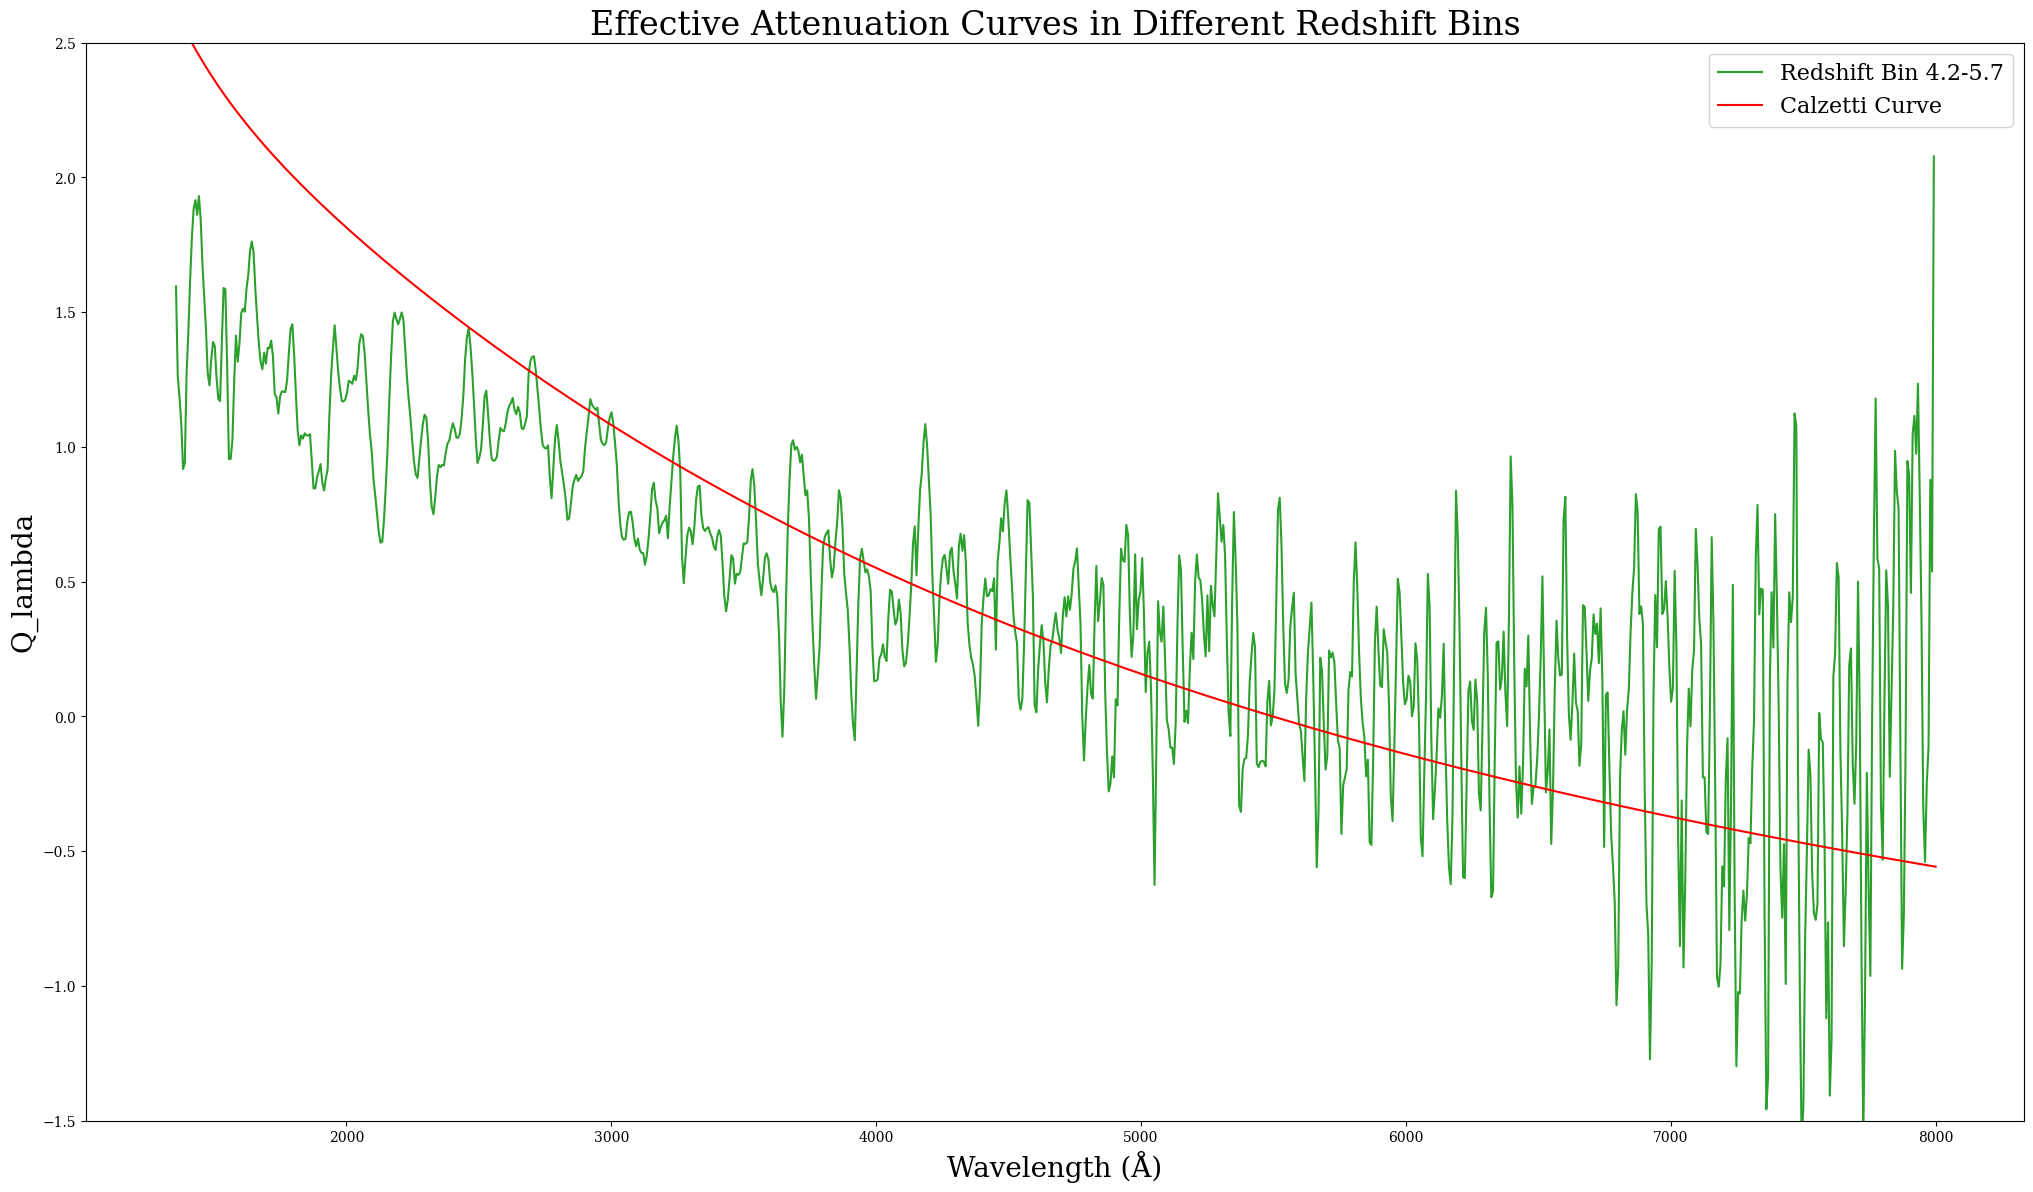

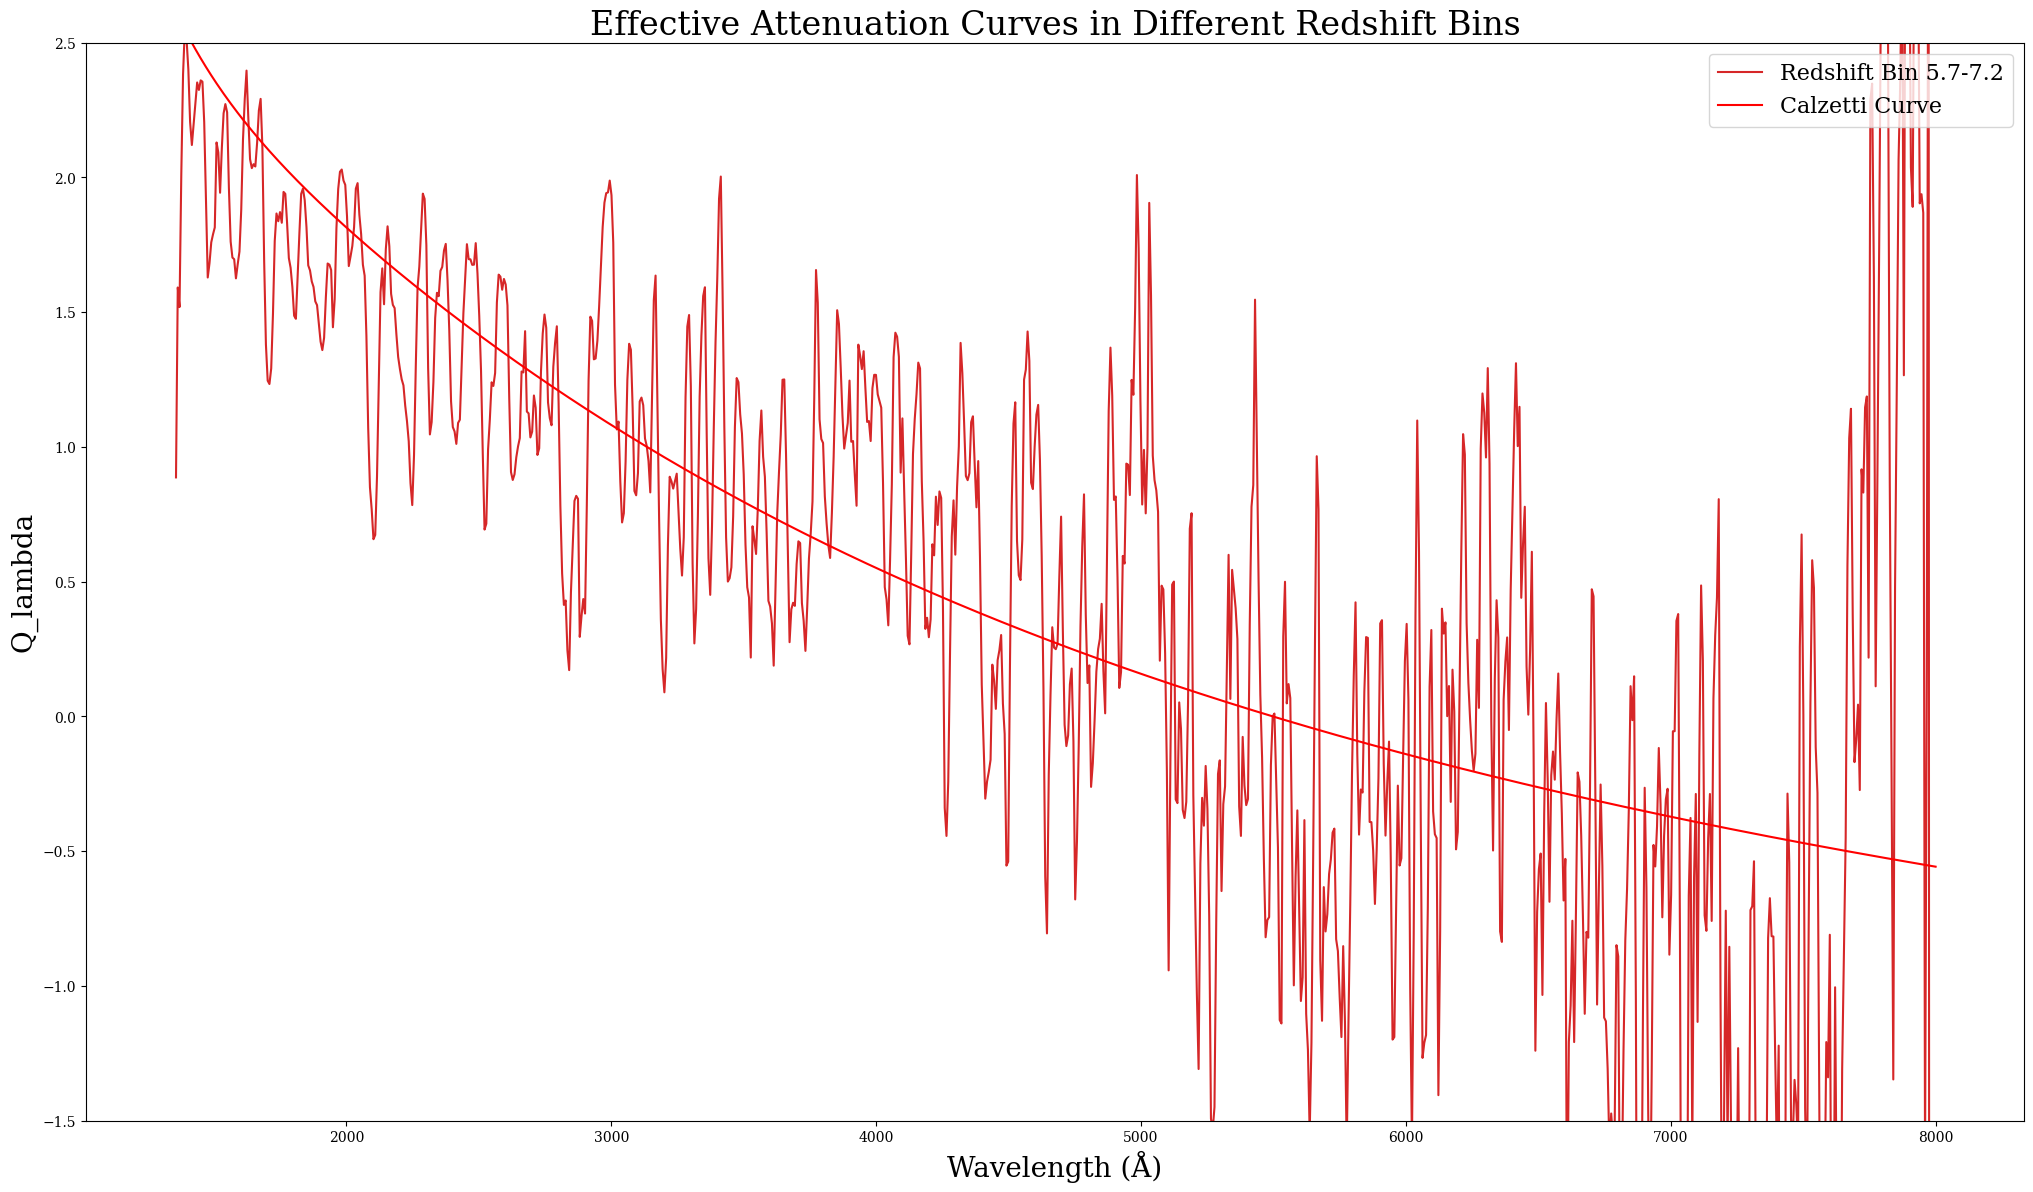

In [56]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

#use sns color palette

colors=sns.color_palette( n_colors=len(redshift_conditions))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)

for redshift_bin_index in range(len(redshift_conditions)):
    fig, ax=plt.subplots(figsize=(25,14))
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[redshift_bin_index]
    ax.plot(common_wavelength, effective_attenuation_curve, label='Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', color=colors[redshift_bin_index])

    ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
    plt.xlabel('Wavelength (Å)', fontsize=20)
    plt.ylabel('Q_lambda', fontsize=20)
    plt.title('Effective Attenuation Curves in Different Redshift Bins', fontsize=24)
    plt.legend(fontsize=16, loc='upper right')
    plt.ylim(-1.5,2.5)
    plt.show()

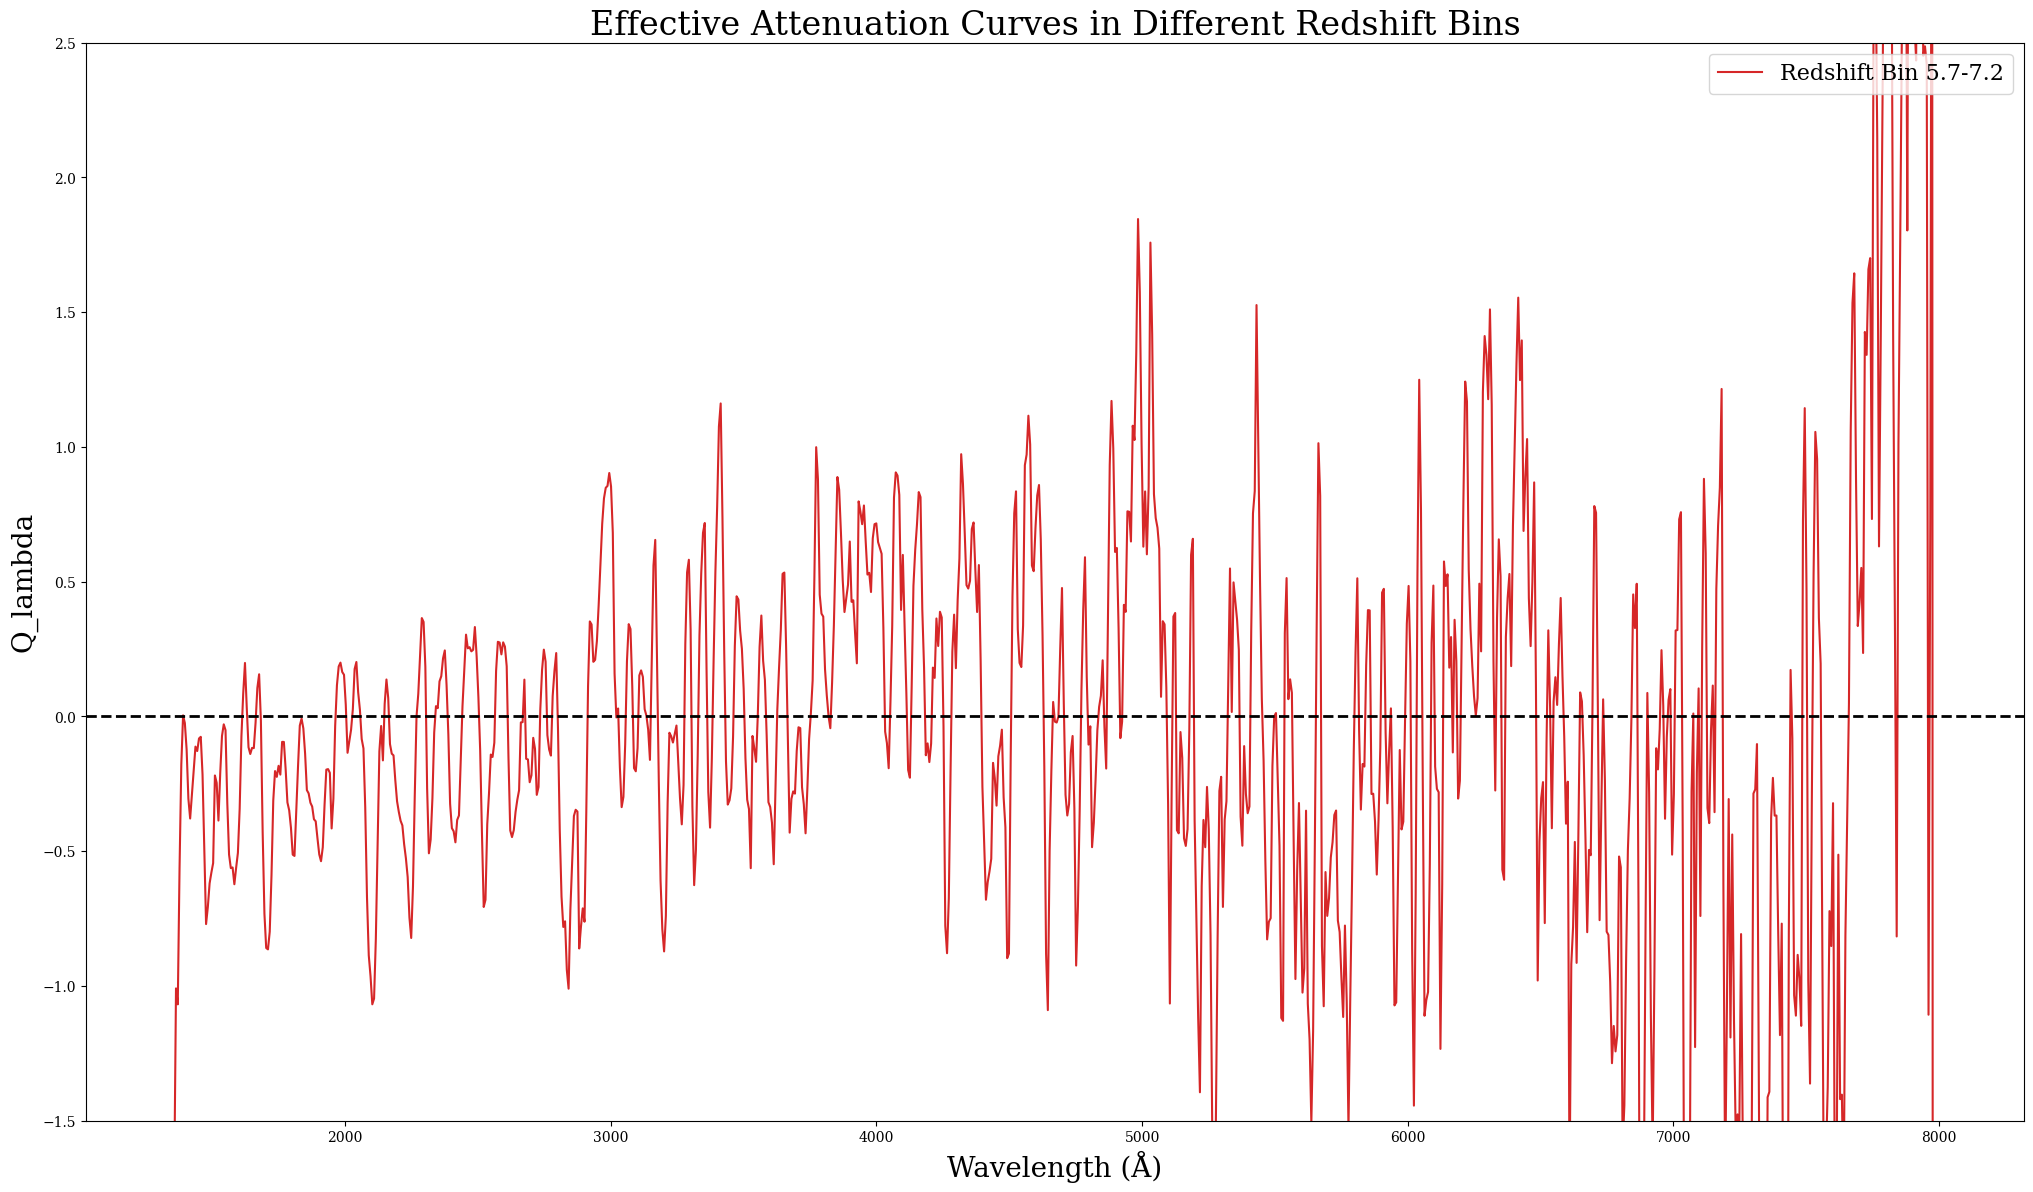

In [58]:

redshift_bin_index=len(redshift_conditions)-1
fig, ax=plt.subplots(figsize=(25,14))
common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[redshift_bin_index]
ax.plot(common_wavelength, effective_attenuation_curve-calzetti_curve, label='Redshift Bin '+f'{redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}', color=colors[redshift_bin_index])

ax.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Redshift Bins', fontsize=24)
plt.legend(fontsize=16, loc='upper right')
plt.ylim(-1.5,2.5)
plt.show()